<a href="https://colab.research.google.com/github/WaskarCS25/SQL_Project_Data_Job_Analysis/blob/main/SVAR_Bolivia_Notebook_FINAL_14_4_26_Marcelo_Choque_Morales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VAR y SVAR aplicado a Bolivia — Notebook unificada y reproducible

Esta notebook integra, en un único flujo, los seis bloques del curso:

1. Preparación, transformaciones y diagnóstico del VAR.
2. Identificación y estimación del SVAR recursivo.
3. Funciones impulso–respuesta (FIR/IRF).
4. Descomposición de varianza del error de pronóstico (FEVD).
5. Identificaciones alternativas.
6. Forecasting VAR/SVAR.

**Diseño reproducible:** todas las funciones necesarias están definidas aquí. No se requiere instalar ni importar paquetes privados de DeepQuantics.

## 0. Instalación e importación de librerías

> **Ejecución recomendada:** use **Kernel → Restart & Run All** (o **Runtime → Run all** en Colab). La notebook está organizada para ejecutarse de principio a fin desde un kernel limpio.

In [9]:
# En Google Colab, descomente únicamente si alguna librería no estuviera disponible:
# !pip -q install pandas numpy scipy statsmodels matplotlib openpyxl

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.optimize import least_squares
from IPython.display import display, Markdown, Math

from statsmodels.tsa.api import VAR
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera

from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
plt.rcParams['figure.dpi'] = 72
plt.rcParams['savefig.dpi'] = 72
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

RANDOM_SEED = 12345
rng = np.random.default_rng(RANDOM_SEED)
print('Entorno listo.')

Entorno listo.


## 1. Carga de la base de datos

In [1]:
from pathlib import Path
import pandas as pd

EXPECTED_FILE = "SVAR 12 meses.xlsx"
LOCAL_PATH = Path(r"/content/SVAR 12 meses.xlsx")

candidate_paths = [
    LOCAL_PATH,
    Path(EXPECTED_FILE),
    Path("SVAR 12 meses.xlsx"),
    Path("/content") / EXPECTED_FILE,
    Path("/content") / "SVAR 12 meses.xlsx",
    Path("/mnt/data") / EXPECTED_FILE,
    Path("/mnt/data") / "SVAR 12 meses.xlsx",
]
DATA_PATH = next((p for p in candidate_paths if p.exists()), None)

if DATA_PATH is None:
    try:
        from google.colab import files
        print(f"Suba el archivo {EXPECTED_FILE}")
        uploaded = files.upload()
        DATA_PATH = Path(next(iter(uploaded.keys())))
    except ImportError as exc:
        raise FileNotFoundError(
            f"No se encontró {EXPECTED_FILE}. Colóquelo junto a la notebook."
        ) from exc

raw = pd.read_excel(DATA_PATH)
print(f"Base cargada desde: {DATA_PATH}")
display(raw.head())
print(f"Dimensiones: {raw.shape[0]} observaciones × {raw.shape[1]} columnas")

Base cargada desde: /content/SVAR 12 meses.xlsx


,Date,Igae,Precio Gas,Crédito,M2
0,2009-01-01,0.026146,-0.344825,0.857393,0.197506
1,2009-02-01,0.031370,-0.471462,0.826826,0.155817
2,2009-03-01,0.021745,-0.579830,0.744098,0.129287
3,2009-04-01,0.020827,-0.654589,0.611028,0.093517
4,2009-05-01,0.019621,-0.660744,0.463318,0.043863


Dimensiones: 192 observaciones × 5 columnas


### 1.1 Estandarización de nombres, fechas y orden estructural

In [5]:
required_columns = ['Date', 'Igae', 'Precio Gas', 'Crédito', 'M2']
missing = [c for c in required_columns if c not in raw.columns]
if missing:
    raise ValueError(f'Faltan columnas requeridas: {missing}')

rename_map = {
    'Igae': 'igae',
    'Precio Gas': 'gas',
    'Crédito': 'credito',
    'M2': 'm2',
}

data = raw[required_columns].rename(columns=rename_map).copy()
data['Date'] = pd.to_datetime(data['Date'])
data = data.set_index('Date').sort_index().asfreq('MS')

if data.isna().any().any():
    print('Advertencia: existen valores faltantes. Se interpolan linealmente solo para mantener el flujo reproducible.')
    data = data.interpolate(method='linear').dropna()

if (data <= 0).any().any():
    problematic_cols = data.columns[(data <= 0).any()]
    print(f'Advertencia: Las siguientes columnas contienen valores no positivos que impiden las transformaciones logarítmicas: {list(problematic_cols)}')
    print('Se reemplazarán los valores no positivos con un pequeño épsilon (1e-9) para permitir el flujo reproducible.')
    data = data.mask(data <= 0, 1e-9)

STRUCTURAL_ORDER = ['gas', 'm2', 'credito', 'igae']
labels = {
    'gas': 'Precio del gas',
    'm2': 'M2',
    'credito': 'Crédito',
    'igae': 'IGAE',
}

data = data[STRUCTURAL_ORDER]
print(f'Muestra: {data.index.min():%Y-%m} a {data.index.max():%Y-%m}')
display(data.describe().T)

Advertencia: Las siguientes columnas contienen valores no positivos que impiden las transformaciones logarítmicas: ['igae', 'gas', 'credito', 'm2']
Se reemplazarán los valores no positivos con un pequeño épsilon (1e-9) para permitir el flujo reproducible.
Muestra: 2009-01 a 2024-12


,count,mean,std,min,25%,50%,75%,max
gas,192.0,0.189148,0.359748,1.000000e-09,1.000000e-09,1.000000e-09,0.198309,1.817234
m2,192.0,0.098401,0.062967,1.000000e-09,4.360293e-02,1.097442e-01,0.146560,0.259854
credito,192.0,0.242064,0.228600,1.000000e-09,6.949617e-02,1.842884e-01,0.349089,0.896275
igae,192.0,0.041916,0.032482,1.000000e-09,2.726363e-02,4.324594e-02,0.053875,0.301885


### 1.2 Visualización de las series en niveles

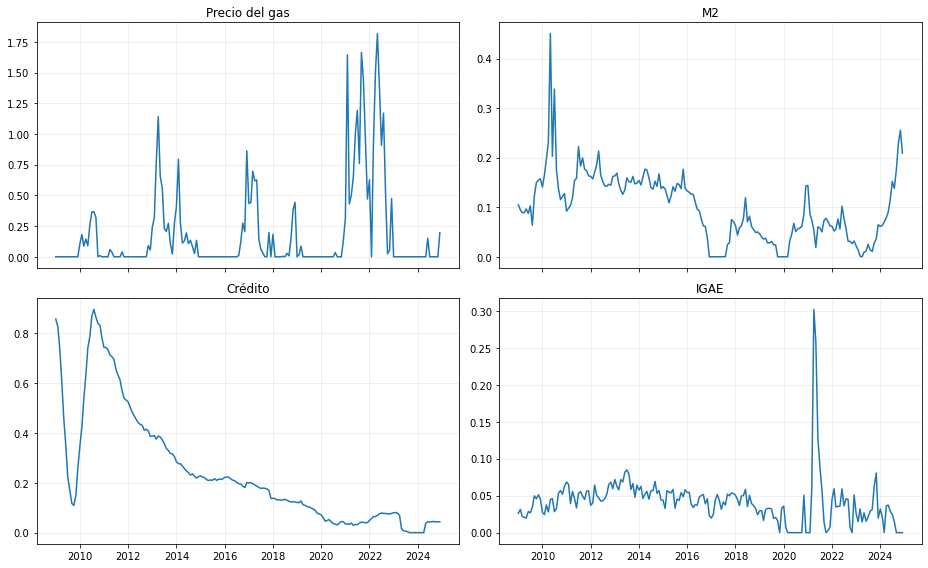

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, col in zip(axes.ravel(), STRUCTURAL_ORDER):
    ax.plot(data.index, data[col])
    ax.set_title(labels[col])
plt.tight_layout()
plt.show()

### 1.3 Desestacionalización de M2

La serie M2 presenta estacionalidad mensual. Antes de aplicar las pruebas de raíz unitaria y estimar el VAR, se elimina el componente estacional mediante STL con periodicidad 12.

$$
\log(M2_t)=T_t+S_t+R_t,
\qquad
\log(M2_t^{SA})=\log(M2_t)-S_t.
$$

Desde este punto, la columna `m2` contiene la serie desestacionalizada. Por tanto, las pruebas ADF y KPSS, la estimación del VAR, las FIR, la FEVD y los pronósticos se realizan con $M2^{SA}$.

,ln_M2_original,componente_estacional,ln_M2_desestacionalizado,M2_desestacionalizado
Date,,,,
2009-01-01,-2.3421,0.0551,-2.3972,0.0910
2009-02-01,-2.4293,0.0455,-2.4748,0.0842
2009-03-01,-2.4659,0.0092,-2.4750,0.0842
2009-04-01,-2.4029,-0.0546,-2.3483,0.0955
2009-05-01,-2.3402,0.0010,-2.3412,0.0962


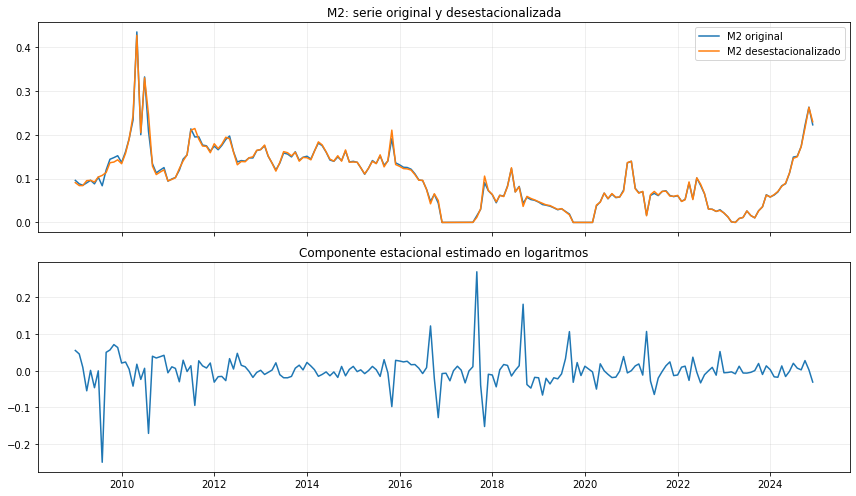

In [38]:
log_m2 = np.log(data['m2'])
stl_m2 = STL(log_m2, period=12, robust=True).fit()

log_m2_sa = log_m2 - stl_m2.seasonal
data_original = data.copy()
data['m2'] = np.exp(log_m2_sa)

seasonal_adjustment = pd.DataFrame({
    'ln_M2_original': log_m2,
    'componente_estacional': stl_m2.seasonal,
    'ln_M2_desestacionalizado': log_m2_sa,
    'M2_desestacionalizado': data['m2']
})
display(seasonal_adjustment.head())

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(data_original.index, data_original['m2'], label='M2 original')
axes[0].plot(data.index, data['m2'], label='M2 desestacionalizado')
axes[0].set_title('M2: serie original y desestacionalizada')
axes[0].legend()
axes[1].plot(stl_m2.seasonal.index, stl_m2.seasonal)
axes[1].set_title('Componente estacional estimado en logaritmos')
plt.tight_layout()
plt.show()

## 2. Transformaciones y representación del VAR reducido

## 1. Transformación de las variables

Se trabaja con **logaritmos** y **primeras diferencias logarítmicas**, de modo que las variables representan tasas aproximadas de crecimiento:

$$
y_t=\Delta\log x_t
=\log x_t-\log x_{t-1}.
$$

## 2. Modelo VAR reducido

El modelo VAR reducido de orden \(p\) se expresa como

$$
y_t
=
c
+
A_1y_{t-1}
+\cdots+
A_py_{t-p}
+
u_t,
\qquad
E(u_tu_t^{\prime})=\Sigma_u.
$$

donde

donde:

- $y_t$ es el vector de variables endógenas.
- $c$ es el vector de interceptos.
- $A_i$ son las matrices de coeficientes.
- $u_t$ representa el vector de innovaciones del VAR reducido.
- $\Sigma_u$ es la matriz de varianzas y covarianzas de las innovaciones.

In [14]:
log_levels = np.log(data)
y = log_levels.diff().dropna()
y.columns = [f'dln_{c}' for c in y.columns]
ORDER = list(y.columns)

print('Orden del sistema:', ORDER)
display(y.head())

Orden del sistema: ['dln_gas', 'dln_m2', 'dln_credito', 'dln_igae']


,dln_gas,dln_m2,dln_credito,dln_igae
Date,,,,
2009-02-01,0.0000,-0.0872,-0.0363,0.1821
2009-03-01,0.0000,-0.0366,-0.1054,-0.3665
2009-04-01,0.0000,0.0629,-0.1970,-0.0431
2009-05-01,0.0000,0.0627,-0.2767,-0.0597
2009-06-01,0.0000,-0.0886,-0.2745,0.3752


### 2.1 Renderización correcta de ecuaciones

In [15]:
# Para ecuaciones se usa display(Math(...)) o celdas Markdown, no print().
display(Math(r'y_t = c + A_1y_{t-1}+\cdots+A_py_{t-p}+u_t'))
display(Math(r'E(u_tu_t^\prime)=\Sigma_u'))
display(Math(r'A_0y_t = c^* + A_1^*y_{t-1}+\cdots+A_p^*y_{t-p}+B\varepsilon_t'))
display(Math(r'u_t=C_0\varepsilon_t,\qquad C_0=A_0^{-1}B'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 2.2 Pruebas ADF y KPSS

In [16]:
def adf_kpss_table(df, alpha=0.05):
    rows=[]
    for col in df.columns:
        s=df[col].dropna()
        adf=adfuller(s, regression='c', autolag='AIC')
        try:
            kp=kpss(s, regression='c', nlags='auto')
            kp_stat, kp_p = kp[0], kp[1]
        except Exception:
            kp_stat, kp_p = np.nan, np.nan
        rows.append({
            'variable':col,
            'ADF stat':adf[0], 'ADF p':adf[1], 'ADF rezagos':adf[2],
            'KPSS stat':kp_stat, 'KPSS p':kp_p,
            'Conclusión': 'Estacionaria' if (adf[1] < alpha and (np.isnan(kp_p) or kp_p > alpha)) else 'Revisar'
        })
    return pd.DataFrame(rows).set_index('variable')

ur_levels = adf_kpss_table(log_levels.rename(columns=lambda c:f'ln_{c}'))
ur_diff = adf_kpss_table(y)
print('Log-niveles')
display(ur_levels)
print('Primeras diferencias logarítmicas')
display(ur_diff)

Log-niveles


/tmp/ipykernel_1021/2156447510.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp=kpss(s, regression='c', nlags='auto')
/tmp/ipykernel_1021/2156447510.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp=kpss(s, regression='c', nlags='auto')
/tmp/ipykernel_1021/2156447510.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp=kpss(s, regression='c', nlags='auto')
/tmp/ipykernel_1021/2156447510.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp=kpss(s, regression='c', nlags='auto')
/tmp/ipykern

,ADF stat,ADF p,ADF rezagos,KPSS stat,KPSS p,Conclusión
variable,,,,,,
ln_gas,-3.9467,0.0017,1,0.0556,0.1000,Estacionaria
ln_m2,-4.0888,0.0010,0,0.2834,0.1000,Estacionaria
ln_credito,1.2911,0.9966,8,0.8165,0.0100,Revisar
ln_igae,-2.3475,0.1571,12,0.6461,0.0184,Revisar


Primeras diferencias logarítmicas


,ADF stat,ADF p,ADF rezagos,KPSS stat,KPSS p,Conclusión
variable,,,,,,
dln_gas,-12.6683,0.0000,1,0.0345,0.1000,Estacionaria
dln_m2,-14.8535,0.0000,0,0.0213,0.1000,Estacionaria
dln_credito,-13.9425,0.0000,7,0.0242,0.1000,Estacionaria
dln_igae,-3.3477,0.0129,15,0.3346,0.1000,Estacionaria


### 2.3 Selección de rezagos y estimación

El objeto `y` contiene todas las variables endógenas incluidas en el VAR. La instrucción `VAR(y)` estima conjuntamente un sistema con todas sus columnas.

Para añadir una nueva variable:

1. incorpórela a la base;
2. añádala a `STRUCTURAL_ORDER`;
3. aplique su transformación y compruebe estacionariedad;
4. vuelva a ejecutar la notebook desde la construcción de `data`.

El resto del flujo se actualiza automáticamente porque `ORDER`, las matrices del VAR, las FIR, la FEVD y los pronósticos se construyen a partir de `y`.

In [17]:
MAX_LAGS = 12
selection = VAR(y).select_order(MAX_LAGS)
display(selection.summary())

# Para mantener coherencia con el material del curso se estima VAR(2).
VAR_LAGS = 2
var_model = VAR(y)
var_fit = var_model.fit(VAR_LAGS, trend='c')
print(var_fit.summary())

,AIC,BIC,FPE,HQIC
0,10.23,10.30*,2.765e+04,10.26
1,9.980,10.34,2.159e+04,10.12*
2,10.07,10.71,2.360e+04,10.33
3,10.14,11.06,2.532e+04,10.51
4,10.11,11.32,2.458e+04,10.60
5,10.12,11.62,2.500e+04,10.73
6,10.16,11.94,2.605e+04,10.88
7,10.22,12.28,2.774e+04,11.06
8,9.271,11.62,1.081e+04,10.22
9,9.152,11.79,9661.,10.22


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 18, Jul, 2026
Time:                     00:31:24
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    10.4911
Nobs:                     189.000    HQIC:                   10.1238
Log likelihood:          -1969.78    FPE:                    19417.4
AIC:                      9.87363    Det(Omega_mle):         16120.4
--------------------------------------------------------------------
Results for equation dln_gas
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.111330         0.492935            0.226           0.821
L1.dln_gas            -0.429677         0.075384           -5.700           0.000
L1.dln_m2             -0.135491         0.173921      

### 2.4 Forma matricial y estimación MCO

In [18]:
def build_var_design(df, lags, add_const=True):
    values=df.to_numpy()
    Y=values[lags:]
    X=[]
    names=[]
    if add_const:
        X.append(np.ones(len(Y)))
        names.append('const')
    for lag in range(1,lags+1):
        X.extend(values[lags-lag:len(values)-lag].T)
        names.extend([f'{c}_L{lag}' for c in df.columns])
    return Y, np.column_stack(X), names

Y_mat, X_mat, x_names = build_var_design(y, VAR_LAGS)
B_ols = np.linalg.lstsq(X_mat, Y_mat, rcond=None)[0]
U_ols = Y_mat - X_mat @ B_ols
Sigma_ml = U_ols.T @ U_ols / len(U_ols)

coef_manual = pd.DataFrame(B_ols, index=x_names, columns=ORDER)
display(coef_manual)
print('Máxima diferencia frente a statsmodels:', np.max(np.abs(B_ols - var_fit.params.to_numpy())))

,dln_gas,dln_m2,dln_credito,dln_igae
const,0.1113,-0.0097,-0.0147,-0.1373
dln_gas_L1,-0.4297,-0.0100,-0.0017,-0.0103
dln_m2_L1,-0.1355,-0.0880,-0.0027,0.1368
dln_credito_L1,0.5752,-0.0008,0.0697,0.0730
dln_igae_L1,-0.0373,-0.1141,0.0674,-0.3795
dln_gas_L2,-0.1180,-0.0070,-0.0032,-0.0070
dln_m2_L2,0.0013,0.0076,-0.0119,-0.1003
dln_credito_L2,-0.3335,-0.0041,0.0076,-0.0363
dln_igae_L2,0.1025,-0.0531,-0.0785,-0.1486


Máxima diferencia frente a statsmodels: 0.0


### 2.5 Estabilidad y diagnósticos residuales

Además de la estabilidad, se evalúan:

- Ljung–Box individual;
- Portmanteau multivariado;
- Jarque–Bera individual y multivariado;
- ARCH-LM individual;
- ARCH-LM multivariado.

Para el ARCH multivariado se usa

$$
z_t=\operatorname{vech}(u_tu_t'),
$$

y se contrasta si los rezagos de $z_t$ explican su dinámica. Bajo la hipótesis nula no existe heterocedasticidad condicional multivariada.

In [20]:
roots = var_fit.roots
stability = pd.DataFrame({
    'raíz inversa': roots,
    'módulo': np.abs(roots),
    'estable (módulo > 1)': np.abs(roots) > 1
})
display(stability)
print('VAR estable:', var_fit.is_stable(verbose=False))

resid = pd.DataFrame(var_fit.resid, index=y.index[VAR_LAGS:], columns=ORDER)

diag = []
for col in ORDER:
    lb = acorr_ljungbox(resid[col], lags=[12], return_df=True).iloc[0]
    jb = jarque_bera(resid[col])
    arch = het_arch(resid[col], nlags=12)
    diag.append({
        'variable': col,
        'Ljung-Box p(12)': lb['lb_pvalue'],
        'Jarque-Bera p': jb[1],
        'ARCH-LM p(12)': arch[1]
    })
print('Diagnósticos individuales')
display(pd.DataFrame(diag).set_index('variable'))

port = var_fit.test_whiteness(nlags=12, adjusted=True)
display(pd.DataFrame([{
    'estadístico': port.test_statistic,
    'gl': port.df,
    'p-valor': port.pvalue,
    'conclusión': 'No se rechaza ausencia de autocorrelación' if port.pvalue > .05 else 'Se rechaza ausencia de autocorrelación'
}], index=['Portmanteau multivariado']))

norm = var_fit.test_normality()
display(pd.DataFrame([{
    'estadístico': norm.test_statistic,
    'gl': norm.df,
    'p-valor': norm.pvalue,
    'conclusión': 'No se rechaza normalidad multivariada' if norm.pvalue > .05 else 'Se rechaza normalidad multivariada'
}], index=['Jarque-Bera multivariado']))

def vech_outer_products(residuals):
    u = np.asarray(residuals)
    tri = np.tril_indices(u.shape[1])
    return np.array([np.outer(row, row)[tri] for row in u])

def multivariate_arch_lm(residuals, lags=12):
    z = vech_outer_products(residuals)
    T, m = z.shape
    Y = z[lags:]
    X = np.column_stack([np.ones(T-lags)] + [z[lags-j:T-j] for j in range(1, lags+1)])
    beta = np.linalg.lstsq(X, Y, rcond=None)[0]
    eu = Y - X @ beta
    er = Y - Y.mean(axis=0, keepdims=True)
    Su = eu.T @ eu / len(Y)
    Sr = er.T @ er / len(Y)
    stat = len(Y) * (np.linalg.slogdet(Sr)[1] - np.linalg.slogdet(Su)[1])
    df = lags * m * m
    pvalue = stats.chi2.sf(stat, df)
    return stat, df, pvalue

arch_stat, arch_df, arch_p = multivariate_arch_lm(resid, lags=12)
display(pd.DataFrame([{
    'estadístico': arch_stat,
    'gl': arch_df,
    'p-valor': arch_p,
    'conclusión': 'No se rechaza ausencia de ARCH multivariado' if arch_p > .05 else 'Se rechaza ausencia de ARCH multivariado'
}], index=['ARCH-LM multivariado']))

,raíz inversa,módulo,estable (módulo > 1)
0,-30.6097-0.0000j,30.6097,True
1,9.6234-0.0000j,9.6234,True
2,5.5906-0.0000j,5.5906,True
3,-3.2055-0.0000j,3.2055,True
4,-1.8058+1.9764j,2.6771,True
5,-1.8058-1.9764j,2.6771,True
6,-0.7151+2.2259j,2.3380,True
7,-0.7151-2.2259j,2.3380,True


VAR estable: True
Diagnósticos individuales


,Ljung-Box p(12),Jarque-Bera p,ARCH-LM p(12)
variable,,,
dln_gas,0.4220,0.0000,0.8846
dln_m2,0.4286,0.0000,0.2741
dln_credito,0.0008,0.0000,0.0000
dln_igae,0.0008,0.0000,0.0001


,estadístico,gl,p-valor,conclusión
Portmanteau multivariado,288.0428,160,0.0000,Se rechaza ausencia de autocorrelación


,estadístico,gl,p-valor,conclusión
Jarque-Bera multivariado,"52,215.1621",8,0.0000,Se rechaza normalidad multivariada


,estadístico,gl,p-valor,conclusión
ARCH-LM multivariado,"9,883.3274",1200,0.0000,Se rechaza ausencia de ARCH multivariado


## 3. Identificación SVAR recursiva

## 2. Identificación estructural

El modelo estructural supone que las innovaciones del VAR reducido pueden expresarse como una combinación lineal de shocks estructurales ortogonales. En particular,

$$
u_t=C_0\varepsilon_t,
\qquad
E(\varepsilon_t\varepsilon_t^{\prime})=I.
$$

En consecuencia, la matriz de varianzas y covarianzas de las innovaciones del VAR reducido viene dada por

$$
\Sigma_u=C_0C_0^{\prime}.
$$

La **identificación recursiva** impone que $(C_0$ sea una **matriz triangular inferior**, restricción que permite recuperar los shocks estructurales mediante la **descomposición de Cholesky** de $\Sigma_u$. En este contexto, el orden de las variables en el sistema adquiere una interpretación económica, ya que determina la estructura contemporánea de las relaciones entre ellas.

donde:

- **$u_t$**: vector $K\times1$ de innovaciones del VAR reducido.
- **$\varepsilon_t$**: vector $K\times1$ de shocks estructurales ortogonales.
- **$C_0$**: matriz $K\times K$ de efectos contemporáneos.
- **$I$**: matriz identidad de dimensión $K\times K$.
- **$\Sigma_u$**: matriz de varianzas y covarianzas de las innovaciones del VAR reducido, definida como
  $$
  \Sigma_u = E(u_tu_t^{\prime}).
  $$

In [21]:
Sigma_u = np.asarray(var_fit.sigma_u_mle)
C0 = np.linalg.cholesky(Sigma_u)
A0 = np.linalg.inv(C0)

sigma_df = pd.DataFrame(Sigma_u, index=ORDER, columns=ORDER)
c0_df = pd.DataFrame(C0, index=ORDER, columns=[f'shock_{c}' for c in ORDER])
a0_df = pd.DataFrame(A0, index=ORDER, columns=ORDER)

print('Matriz de covarianza reducida Σ_u')
display(sigma_df)
print('Matriz de impacto contemporáneo C_0')
display(c0_df)
print('Matriz estructural A_0=C_0^{-1}')
display(a0_df)
print('Error de reconstrucción ||Σ_u-C_0C_0\' ||:', np.max(np.abs(Sigma_u-C0@C0.T)))

Matriz de covarianza reducida Σ_u


,dln_gas,dln_m2,dln_credito,dln_igae
dln_gas,43.6690,-0.3703,0.2514,-1.5636
dln_m2,-0.3703,7.9929,0.0312,-0.3819
dln_credito,0.2514,0.0312,2.5987,0.3833
dln_igae,-1.5636,-0.3819,0.3833,14.7712


Matriz de impacto contemporáneo C_0


,shock_dln_gas,shock_dln_m2,shock_dln_credito,shock_dln_igae
dln_gas,6.6083,0.0000,0.0000,0.0000
dln_m2,-0.0560,2.8266,0.0000,0.0000
dln_credito,0.0381,0.0118,1.6116,0.0000
dln_igae,-0.2366,-0.1398,0.2444,3.8257


Matriz estructural A_0=C_0^{-1}


,dln_gas,dln_m2,dln_credito,dln_igae
dln_gas,0.1513,0.0000,0.0000,0.0000
dln_m2,0.0030,0.3538,0.0000,0.0000
dln_credito,-0.0036,-0.0026,0.6205,0.0000
dln_igae,0.0097,0.0131,-0.0396,0.2614


Error de reconstrucción ||Σ_u-C_0C_0' ||: 1.7763568394002505e-15


### 3.1 Identificación contemporánea con restricciones editables

Cholesky es una identificación recursiva, pero no es la única posibilidad. Con shocks normalizados,

$$
\Sigma_u=C_0C_0',
$$

la matriz $C_0$ contiene $K^2$ elementos, mientras que $\Sigma_u$ aporta $K(K+1)/2$ ecuaciones independientes. Por ello se requieren al menos

$$
K^2-\frac{K(K+1)}{2}=\frac{K(K-1)}{2}
$$

restricciones adicionales para una identificación exacta.

La siguiente plantilla permite fijar ceros u otros valores directamente en $C_0$. Use `np.nan` para parámetros libres y un número para parámetros restringidos.

In [22]:
def estimate_impact_with_restrictions(sigma_u, restriction_matrix, start=None):
    R = np.asarray(restriction_matrix, dtype=float)
    k = R.shape[0]
    free = np.isnan(R)
    n_required = k * (k - 1) // 2
    n_fixed = np.size(R) - free.sum()

    print(f'Restricciones fijadas: {n_fixed}. Mínimo orientativo para identificación exacta: {n_required}.')

    if start is None:
        C_start = np.linalg.cholesky(sigma_u)
    else:
        C_start = np.asarray(start, dtype=float)

    x0 = C_start[free]

    def unpack(x):
        C = R.copy()
        C[free] = x
        return C

    tri = np.tril_indices(k)
    def objective(x):
        C = unpack(x)
        return (C @ C.T - sigma_u)[tri]

    result = least_squares(objective, x0)
    C_hat = unpack(result.x)

    if not result.success:
        raise RuntimeError(result.message)
    return C_hat, result

# Ejemplo equivalente a Cholesky: ceros por encima de la diagonal.
# Cambie los ceros y np.nan para imponer otra estructura contemporánea.
C0_restrictions = np.full((len(ORDER), len(ORDER)), np.nan)
C0_restrictions[np.triu_indices(len(ORDER), k=1)] = 0.0

C0_custom, custom_result = estimate_impact_with_restrictions(
    Sigma_u, C0_restrictions, start=C0
)

display(pd.DataFrame(C0_custom, index=ORDER, columns=[f'shock_{c}' for c in ORDER]))
print('Error de reconstrucción:', np.linalg.norm(Sigma_u - C0_custom @ C0_custom.T))

Restricciones fijadas: 6. Mínimo orientativo para identificación exacta: 6.


,shock_dln_gas,shock_dln_m2,shock_dln_credito,shock_dln_igae
dln_gas,6.6083,0.0000,0.0000,0.0000
dln_m2,-0.0560,2.8266,0.0000,0.0000
dln_credito,0.0381,0.0118,1.6116,0.0000
dln_igae,-0.2366,-0.1398,0.2444,3.8257


Error de reconstrucción: 2.013768150762661e-15


## Verificación de la descomposición de Cholesky

Una vez estimado el SVAR mediante identificación recursiva, es conveniente verificar que la descomposición de Cholesky reconstruye correctamente la matriz de varianzas y covarianzas de los residuos del VAR reducido.

En teoría, debe cumplirse exactamente que

$$
\Sigma_u=C_0C_0^{\prime}.
$$

donde:

- $\Sigma_u$ es la matriz de varianzas y covarianzas estimada de los residuos del VAR reducido.
- $C_0$ es la matriz de efectos contemporáneos obtenida mediante la descomposición de Cholesky.

Para comprobar esta igualdad, el algoritmo vuelve a calcular el producto

$$
C_0C_0^{\prime},
$$

y lo compara con la matriz original $\Sigma_u$. La diferencia entre ambas matrices es

$$
\Sigma_u-C_0C_0^{\prime}.
$$

### Error numérico de reconstrucción

El valor que reporta la notebook es

$$
\left\|\Sigma_u-C_0C_0^{\prime}\right\|,
$$

donde $\|\cdot\|$ representa la **norma de una matriz**. En lugar de mostrar toda la matriz diferencia, se resume dicha diferencia mediante un único número que mide su magnitud.

En Python, este valor se calcula mediante:

```python
np.linalg.norm(Sigma_u - C0 @ C0.T)
```

### Interpretación

Idealmente,

$$
\Sigma_u=C_0C_0^{\prime},
$$

por lo que debería cumplirse

$$
\left\|\Sigma_u-C_0C_0^{\prime}\right\|=0.
$$

Sin embargo, debido a la aritmética en punto flotante utilizada por los computadores, normalmente se obtienen valores extremadamente pequeños, por ejemplo:

```text
2.3e-15
```

o

```text
8.7e-16
```

Estos valores **no representan un error de identificación**, sino únicamente errores numéricos de redondeo.

### Conclusión

Si el error numérico de reconstrucción es del orden de $10^{-15}$ o menor, puede concluirse que la descomposición de Cholesky reconstruye correctamente la matriz $\Sigma_u$ y que la identificación estructural se ha realizado satisfactoriamente.

Por ejemplo:

```text
Verificación de la descomposición de Cholesky

||Σu − C₀C₀′|| = 3.8×10⁻¹⁵

✓ La diferencia es prácticamente nula.
✓ La descomposición de Cholesky reconstruye correctamente la matriz Σu.
```

### 3.1 Shocks estructurales estimados

,count,mean,std,min,25%,50%,75%,max
eps_dln_gas,189.0000,-0.0000,1.0027,-3.0957,-0.1649,-0.0178,0.1082,2.9156
eps_dln_m2,189.0000,0.0000,1.0027,-6.2124,-0.0598,-0.0039,0.0595,5.6203
eps_dln_credito,189.0000,0.0000,1.0027,-9.3085,-0.0341,0.0027,0.0434,9.2787
eps_dln_igae,189.0000,-0.0000,1.0027,-4.4047,-0.0345,0.0373,0.1234,4.7390


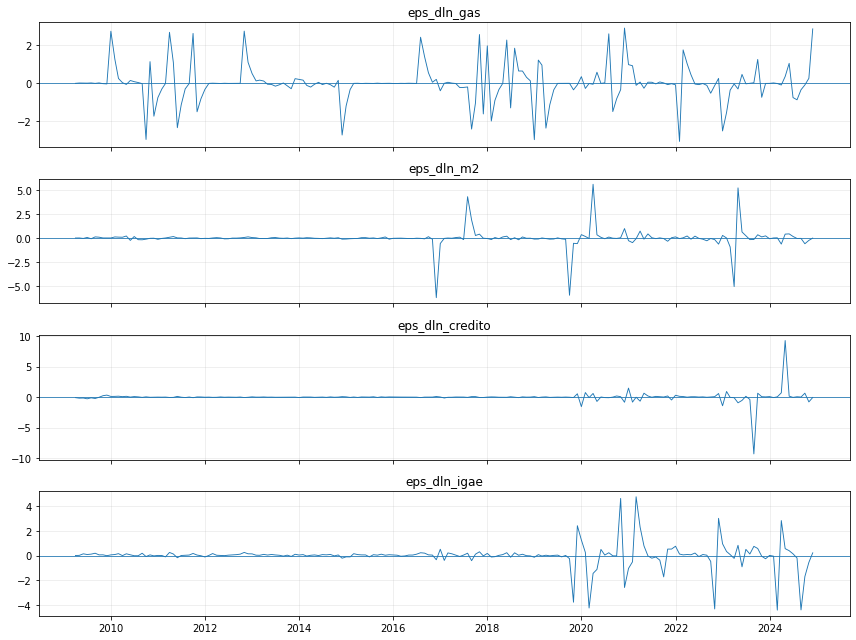

In [23]:
# u_t = C0 ε_t  =>  ε_t = C0^{-1}u_t

structural_shocks = pd.DataFrame(
    np.linalg.solve(C0, resid.to_numpy().T).T,
    index=resid.index,
    columns=[f"eps_{c}" for c in ORDER]
)

display(structural_shocks.describe().T)

fig, axes = plt.subplots(
    len(ORDER),
    1,
    figsize=(12, 9),
    sharex=True
)

for ax, col in zip(axes, structural_shocks.columns):
    ax.plot(
        structural_shocks.index,
        structural_shocks[col],
        lw=0.9
    )
    ax.axhline(0, lw=0.8)
    ax.set_title(col)

plt.tight_layout()
plt.show()

## 4. Funciones impulso–respuesta estructurales

La representación VMA es

$$
y_t=\mu+\sum_{h=0}^{\infty}\Phi_hu_{t-h},
\qquad
\Theta_h=\Phi_hC_0.
$$

Para cuantificar la incertidumbre se utiliza bootstrap residual. En cada réplica se remuestrean residuos, se simula una nueva muestra, se reestima el VAR y se recalculan las FIR. Para cada horizonte y cada par respuesta–shock se obtiene una distribución empírica.

La banda bootstrap bilateral de 95% se construye con los percentiles 2.5 y 97.5:

$$
\left[
\widehat{\Theta}_{h,ij}^{*(0.025)},
\widehat{\Theta}_{h,ij}^{*(0.975)}
\right].
$$

No equivale, en general, a sumar y restar una desviación estándar. Esa aproximación solo sería válida bajo normalidad y simetría. El bootstrap permite bandas asimétricas.

In [24]:
def ma_matrices(coefs, horizon):
    p,k,_=coefs.shape
    Phi=np.zeros((horizon+1,k,k))
    Phi[0]=np.eye(k)
    for h in range(1,horizon+1):
        for lag in range(1,min(p,h)+1):
            Phi[h] += coefs[lag-1] @ Phi[h-lag]
    return Phi

def structural_irfs(coefs, impact, horizon):
    return np.einsum('hij,jk->hik', ma_matrices(coefs,horizon), impact)

H=36
Phi=ma_matrices(np.asarray(var_fit.coefs),H)
IRF=structural_irfs(np.asarray(var_fit.coefs),C0,H)
print('Dimensión IRF:',IRF.shape)

Dimensión IRF: (37, 4, 4)


### 4.1 Panel completo de FIR

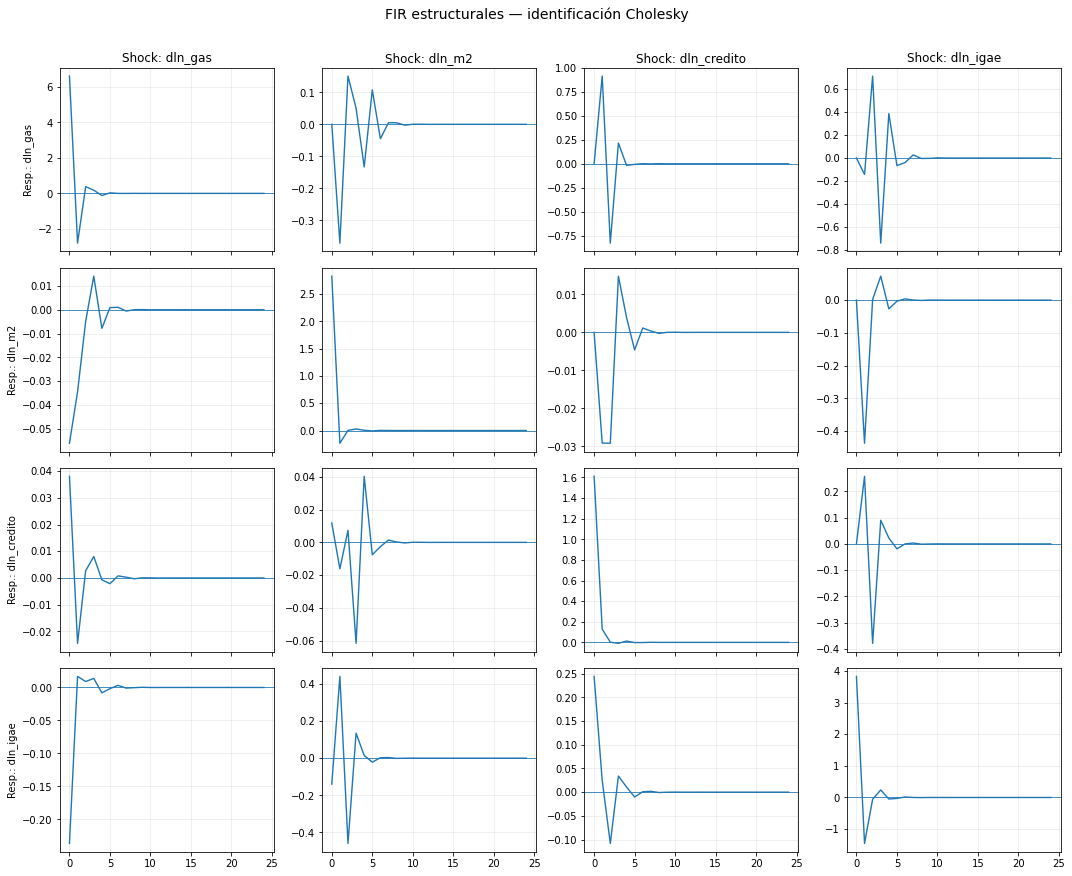

In [25]:
def plot_irf_panel(irf, names, horizon=None, title='Funciones impulso–respuesta'):
    if horizon is None: horizon=irf.shape[0]-1
    k=len(names)
    fig,axes=plt.subplots(k,k,figsize=(15,12),sharex=True)
    x=np.arange(horizon+1)
    for i in range(k):
        for j in range(k):
            ax=axes[i,j]
            ax.plot(x,irf[:horizon+1,i,j],lw=1.4)
            ax.axhline(0,lw=.8)
            if i==0: ax.set_title(f'Shock: {names[j]}')
            if j==0: ax.set_ylabel(f'Resp.: {names[i]}')
    fig.suptitle(title,y=1.01,fontsize=14)
    plt.tight_layout(); plt.show()

plot_irf_panel(IRF, ORDER, 24, 'FIR estructurales — identificación Cholesky')

### 4.2 Casos seleccionados y respuestas acumuladas

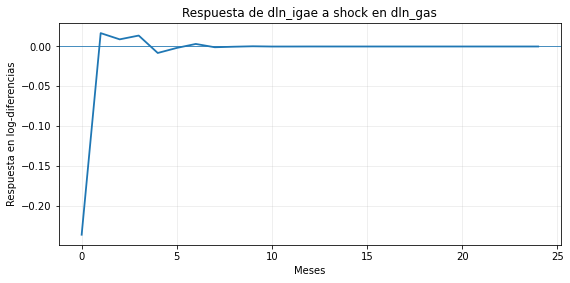

,h,respuesta
0,0,-0.2366
1,1,0.0168
2,2,0.0090
3,3,0.0138
4,4,-0.0082
5,5,-0.0018
6,6,0.0032
7,7,-0.0010
8,8,-0.0003
9,9,0.0003


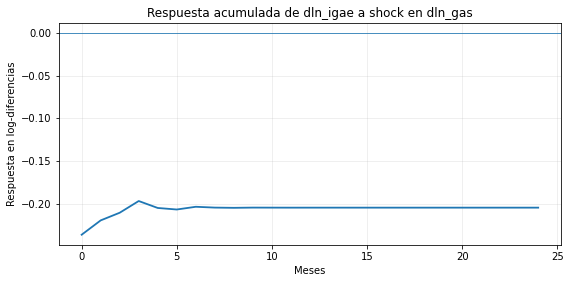

In [26]:
def plot_irf_case(irf,response,shock,horizon=24,cumulative=False):
    i=ORDER.index(response); j=ORDER.index(shock)
    values=irf[:horizon+1,i,j]
    if cumulative: values=values.cumsum()
    plt.figure(figsize=(9,4))
    plt.plot(range(horizon+1),values,lw=1.8)
    plt.axhline(0,lw=.8)
    plt.title(f"Respuesta {'acumulada ' if cumulative else ''}de {response} a shock en {shock}")
    plt.xlabel('Meses'); plt.ylabel('Respuesta en log-diferencias')
    plt.show()
    return pd.DataFrame({'h':range(horizon+1),'respuesta':values})

selected_irf = plot_irf_case(IRF,'dln_igae','dln_gas',24)
display(selected_irf.head(12))
plot_irf_case(IRF,'dln_igae','dln_gas',24,cumulative=True);

### 4.3 Bandas bootstrap de 95%, errores estándar y resultados numéricos

Las funciones impulso-respuesta son estimaciones y, por tanto, están sujetas a incertidumbre muestral. Un gráfico de la FIR puntual no permite determinar por sí solo si una respuesta es estadísticamente distinta de cero. Para evaluar esa incertidumbre se construyen intervalos de confianza.

En un enfoque paramétrico normal, un intervalo bilateral aproximado de 95% se escribiría como

$$
\widehat{\theta}_{ij,h}
\pm
1.96\,\widehat{\operatorname{se}}\!\left(\widehat{\theta}_{ij,h}\right).
$$

Este procedimiento supone que la distribución muestral de la FIR es aproximadamente normal y simétrica. Sin embargo, las funciones impulso-respuesta son transformaciones no lineales de los coeficientes del VAR y de la matriz de impacto estructural. Por ello, su distribución puede ser asimétrica, especialmente en muestras pequeñas.

#### Bootstrap residual

La notebook utiliza un **bootstrap residual**. El procedimiento reproduce artificialmente la incertidumbre muestral mediante las siguientes etapas:

1. Se estima el VAR original y se obtienen los residuos reducidos $\widehat u_t$.
2. Se remuestrean esos residuos con reemplazo para obtener $u_t^{*(b)}$.
3. Se genera una trayectoria artificial usando los coeficientes estimados del VAR:

$$
y_t^{*(b)}
=
\widehat c
+
\sum_{\ell=1}^{p}\widehat A_{\ell}y_{t-\ell}^{*(b)}
+
u_t^{*(b)}.
$$

4. Se reestima el VAR sobre cada muestra artificial.
5. Se identifica nuevamente la matriz estructural mediante Cholesky.
6. Se calculan las FIR bootstrap $\widehat\Theta_h^{*(b)}$.

Después de $B$ réplicas se obtiene una distribución empírica para cada respuesta. Las bandas percentiles de 95% se construyen como

$$
IC_{0.95}(\theta_{ij,h})
=
\left[
q_{0.025}\!\left(\widehat\theta_{ij,h}^{*}\right),
q_{0.975}\!\left(\widehat\theta_{ij,h}^{*}\right)
\right].
$$

A diferencia del intervalo normal $\widehat\theta\pm1.96\,\widehat{se}(\widehat\theta)$, las bandas percentiles no obligan a que el intervalo sea simétrico alrededor de la estimación puntual. Esto resulta especialmente útil cuando la distribución bootstrap es sesgada o asimétrica.

La desviación estándar bootstrap se calcula como

$$
\widehat{\operatorname{se}}_{\mathrm{boot}}
\left(\widehat\theta_{ij,h}\right)
=
\sqrt{
\frac{1}{B-1}
\sum_{b=1}^{B}
\left(
\widehat\theta_{ij,h}^{*(b)}
-
\overline{\theta}_{ij,h}^{*}
\right)^2
}.
$$

Una respuesta se interpreta como estadísticamente distinta de cero al 5% cuando la banda bootstrap de 95% no contiene el valor cero. Esta interpretación debe complementarse con la magnitud económica, persistencia y coherencia teórica de la respuesta.

In [27]:
def bootstrap_irfs(
    fit,
    data_df,
    horizon=24,
    n_boot=300,
    seed=12345
):
    """Bootstrap residual autocontenido para FIR estructurales.

    En cada réplica:
      1. remuestrea residuos del VAR reducido;
      2. simula una trayectoria artificial;
      3. reestima el VAR por MCO matricial;
      4. identifica C0 mediante Cholesky;
      5. calcula las FIR estructurales.

    Returns
    -------
    np.ndarray
        Dimensiones: réplicas × horizontes × variables × shocks.
    """
    rg = np.random.default_rng(seed)

    p = fit.k_ar
    k = fit.neqs
    T = len(data_df)

    coefs = np.asarray(fit.coefs, dtype=float)
    intercept = np.asarray(fit.intercept, dtype=float)
    residuals = np.asarray(fit.resid, dtype=float)
    initial = np.asarray(data_df.iloc[:p], dtype=float)

    def build_design_matrix(values, lags):
        """Construye Y y X para un VAR(p) con constante."""
        values = np.asarray(values, dtype=float)
        n_obs, _ = values.shape
        if n_obs <= lags:
            raise ValueError("Observaciones insuficientes para construir el VAR.")

        Y = values[lags:]
        X_blocks = [np.ones((n_obs - lags, 1))]
        for lag in range(1, lags + 1):
            X_blocks.append(values[lags-lag:n_obs-lag])
        X = np.hstack(X_blocks)
        return Y, X

    draws = []

    for _ in range(n_boot):
        sampled = residuals[
            rg.integers(0, len(residuals), size=T-p)
        ]

        sim = np.zeros((T, k), dtype=float)
        sim[:p] = initial

        for t in range(p, T):
            pred_t = intercept.copy()
            for lag in range(1, p + 1):
                pred_t += coefs[lag - 1] @ sim[t - lag]
            sim[t] = pred_t + sampled[t - p]

        Y_b, X_b = build_design_matrix(sim, p)
        B_b = np.linalg.lstsq(X_b, Y_b, rcond=None)[0]
        U_b = Y_b - X_b @ B_b
        Sigma_b = U_b.T @ U_b / len(U_b)

        try:
            impact_b = np.linalg.cholesky(Sigma_b)
        except np.linalg.LinAlgError:
            continue

        coefs_b = np.empty((p, k, k), dtype=float)
        for lag in range(p):
            start = 1 + lag*k
            end = start + k
            coefs_b[lag] = B_b[start:end].T

        draws.append(
            structural_irfs(coefs_b, impact_b, horizon)
        )

    if len(draws) < 2:
        raise RuntimeError(
            "El bootstrap produjo menos de dos réplicas válidas. "
            "Revise la especificación y la estabilidad del VAR."
        )

    return np.stack(draws, axis=0)


N_BOOT_IRF = 300

boot_irf = bootstrap_irfs(
    fit=var_fit,
    data_df=y,
    horizon=H,
    n_boot=N_BOOT_IRF,
    seed=RANDOM_SEED
)

# FIR no acumuladas
irf_se = boot_irf.std(axis=0, ddof=1)
irf_lo = np.quantile(boot_irf, 0.025, axis=0)
irf_hi = np.quantile(boot_irf, 0.975, axis=0)

# FIR acumuladas
boot_cum = boot_irf.cumsum(axis=1)
IRF_cum = IRF.cumsum(axis=0)
cum_se = boot_cum.std(axis=0, ddof=1)
cum_lo = np.quantile(boot_cum, 0.025, axis=0)
cum_hi = np.quantile(boot_cum, 0.975, axis=0)

print("Réplicas bootstrap solicitadas:", N_BOOT_IRF)
print("Réplicas bootstrap válidas:", len(boot_irf))
print("Dimensiones del arreglo bootstrap:", boot_irf.shape)

Réplicas bootstrap solicitadas: 300
Réplicas bootstrap válidas: 300
Dimensiones del arreglo bootstrap: (300, 37, 4, 4)


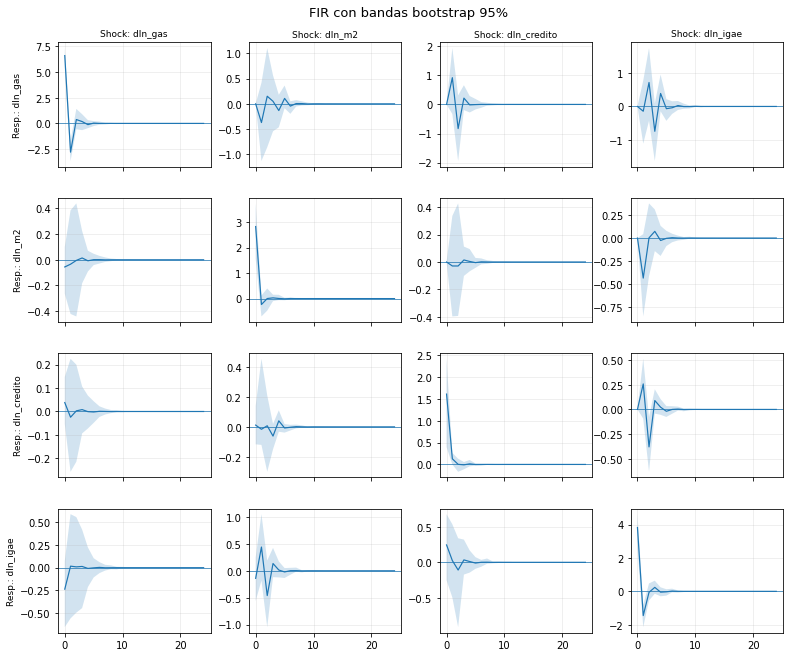

In [28]:
def plot_irf_bands_panel(point, lower, upper, names, horizon=24,
                         title="FIR con bandas bootstrap 95%"):
    k = len(names)
    x = np.arange(horizon + 1)
    fig, axes = plt.subplots(k, k, figsize=(13, 10), sharex=True, dpi=72)
    for i in range(k):
        for j in range(k):
            ax = axes[i, j]
            ax.plot(x, point[:horizon+1, i, j], lw=1.2)
            ax.fill_between(
                x,
                lower[:horizon+1, i, j],
                upper[:horizon+1, i, j],
                alpha=0.20,
                linewidth=0
            )
            ax.axhline(0, lw=0.7)
            if i == 0:
                ax.set_title(f"Shock: {names[j]}", fontsize=9)
            if j == 0:
                ax.set_ylabel(f"Resp.: {names[i]}", fontsize=9)
    fig.suptitle(title, fontsize=13)
    fig.subplots_adjust(top=0.93, hspace=0.25, wspace=0.25)
    plt.show()
    plt.close(fig)

plot_irf_bands_panel(
    IRF, irf_lo, irf_hi, ORDER, horizon=24,
    title="FIR con bandas bootstrap 95%"
)


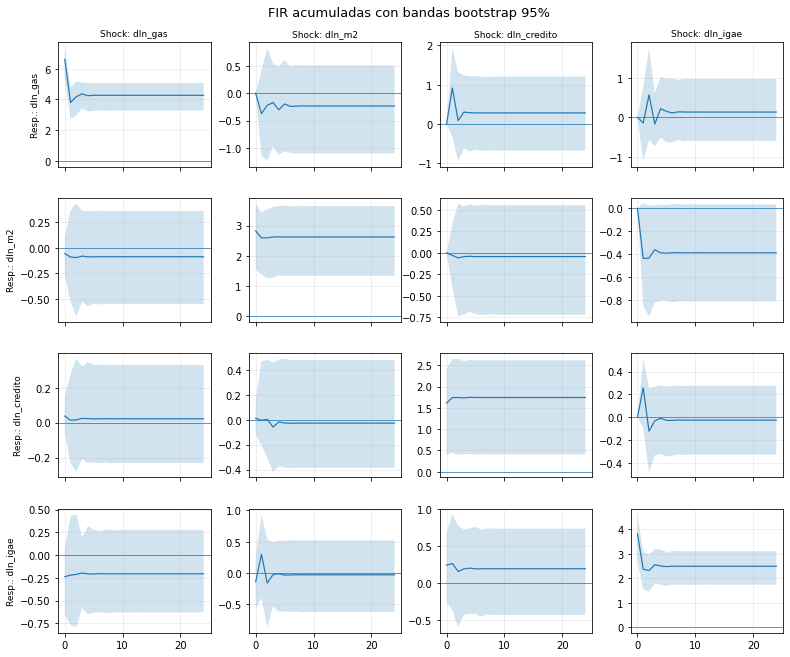

In [29]:
plot_irf_bands_panel(
    IRF_cum, cum_lo, cum_hi, ORDER, horizon=24,
    title="FIR acumuladas con bandas bootstrap 95%"
)

In [30]:
def irf_numeric_table(point, se, lower, upper, cumulative=False, horizon=24):
    rows = []
    for i, response in enumerate(ORDER):
        for j, shock in enumerate(ORDER):
            for h in range(horizon+1):
                rows.append({
                    'respuesta': response,
                    'shock': shock,
                    'horizonte': h,
                    'estimación': point[h, i, j],
                    'error estándar bootstrap': se[h, i, j],
                    'límite inferior 95%': lower[h, i, j],
                    'límite superior 95%': upper[h, i, j],
                    'acumulada': cumulative
                })
    return pd.DataFrame(rows)

irf_numbers = irf_numeric_table(IRF, irf_se, irf_lo, irf_hi, cumulative=False)
cum_irf_numbers = irf_numeric_table(IRF_cum, cum_se, cum_lo, cum_hi, cumulative=True)

print('Primeras filas de las FIR no acumuladas')
print(irf_numbers.head(20).to_string(index=False))
print('Primeras filas de las FIR acumuladas')
print(cum_irf_numbers.head(20).to_string(index=False))

Primeras filas de las FIR no acumuladas
respuesta   shock  horizonte  estimación  error estándar bootstrap  límite inferior 95%  límite superior 95%  acumulada
  dln_gas dln_gas          0      6.6083                    0.5088               5.3949               7.3438      False
  dln_gas dln_gas          1     -2.8011                    0.4944              -3.6678              -1.7129      False
  dln_gas dln_gas          2      0.3769                    0.5277              -0.5645               1.4154      False
  dln_gas dln_gas          3      0.1803                    0.4084              -0.6591               0.8970      False
  dln_gas dln_gas          4     -0.1197                    0.2028              -0.4641               0.3190      False
  dln_gas dln_gas          5      0.0299                    0.1151              -0.2610               0.2230      False
  dln_gas dln_gas          6     -0.0006                    0.0741              -0.1254               0.1804      False


## 5. FEVD estructural

## Descomposición de la varianza del error de pronóstico

Para la variable $i$, la participación del shock estructural $j$ en la varianza del error de pronóstico al horizonte $H$ se define como

$$
\omega_{ij}(H)
=
\frac{
\displaystyle\sum_{h=0}^{H-1}\theta_{ij,h}^{\,2}
}{
\displaystyle\sum_{h=0}^{H-1}\sum_{m=1}^{K}\theta_{im,h}^{\,2}
}.
$$

donde:

- $\omega_{ij}(H)$ es la proporción de la varianza del error de pronóstico de la variable $i$ atribuible al shock estructural $j$ en el horizonte $H$.
- $\theta_{ij,h}$ es la respuesta de la variable $i$ ante el shock estructural $j$ en el horizonte $h$.
- $K$ es el número de shocks estructurales del sistema.
- $H$ es el horizonte de pronóstico considerado.

El numerador acumula, desde $h=0$ hasta $h=H-1$, la contribución del shock $j$ a la incertidumbre de pronóstico de la variable $i$. El denominador acumula la contribución de todos los shocks estructurales a la varianza total del error de pronóstico de esa variable.

Por construcción,

$$
0\leq \omega_{ij}(H)\leq 1,
$$

y, para cada variable $i$ y horizonte $H$,

$$
\sum_{j=1}^{K}\omega_{ij}(H)=1.
$$

Por tanto, al expresarse en porcentajes,

$$
100\times\omega_{ij}(H)
$$

indica el porcentaje de la varianza del error de pronóstico de la variable $i$ explicado por el shock estructural $j$.

In [31]:
def compute_fevd(irf):
    sq=irf**2
    cum=np.cumsum(sq,axis=0)
    den=cum.sum(axis=2,keepdims=True)
    return cum/den

FEVD=compute_fevd(IRF)
HORIZONS=[1,6,12,24,36]

def fevd_table(fevd,horizon):
    idx=horizon-1
    return pd.DataFrame(fevd[idx],index=ORDER,columns=[f'shock_{c}' for c in ORDER])

for h in HORIZONS:
    print(f'FEVD — horizonte {h}')
    display((100*fevd_table(FEVD,h)).round(2))

FEVD — horizonte 1


,shock_dln_gas,shock_dln_m2,shock_dln_credito,shock_dln_igae
dln_gas,100.0000,0.0000,0.0000,0.0000
dln_m2,0.0400,99.9600,0.0000,0.0000
dln_credito,0.0600,0.0100,99.9400,0.0000
dln_igae,0.3800,0.1300,0.4000,99.0800


FEVD — horizonte 6


,shock_dln_gas,shock_dln_m2,shock_dln_credito,shock_dln_igae
dln_gas,94.5000,0.3500,2.8800,2.2600
dln_m2,0.0600,97.5400,0.0200,2.3800
dln_credito,0.0700,0.2100,92.0100,7.7100
dln_igae,0.3300,2.5500,0.4200,96.7000


FEVD — horizonte 12


,shock_dln_gas,shock_dln_m2,shock_dln_credito,shock_dln_igae
dln_gas,94.5000,0.3500,2.8800,2.2600
dln_m2,0.0600,97.5400,0.0200,2.3800
dln_credito,0.0700,0.2100,92.0000,7.7100
dln_igae,0.3300,2.5500,0.4200,96.7000


FEVD — horizonte 24


,shock_dln_gas,shock_dln_m2,shock_dln_credito,shock_dln_igae
dln_gas,94.5000,0.3500,2.8800,2.2600
dln_m2,0.0600,97.5400,0.0200,2.3800
dln_credito,0.0700,0.2100,92.0000,7.7100
dln_igae,0.3300,2.5500,0.4200,96.7000


FEVD — horizonte 36


,shock_dln_gas,shock_dln_m2,shock_dln_credito,shock_dln_igae
dln_gas,94.5000,0.3500,2.8800,2.2600
dln_m2,0.0600,97.5400,0.0200,2.3800
dln_credito,0.0700,0.2100,92.0000,7.7100
dln_igae,0.3300,2.5500,0.4200,96.7000


### 5.1 Representación de la FEVD mediante barras apiladas

Para cada variable y horizonte, las contribuciones de todos los shocks suman 100%. Las barras apiladas permiten visualizar con mayor claridad la composición de la varianza del error de pronóstico.

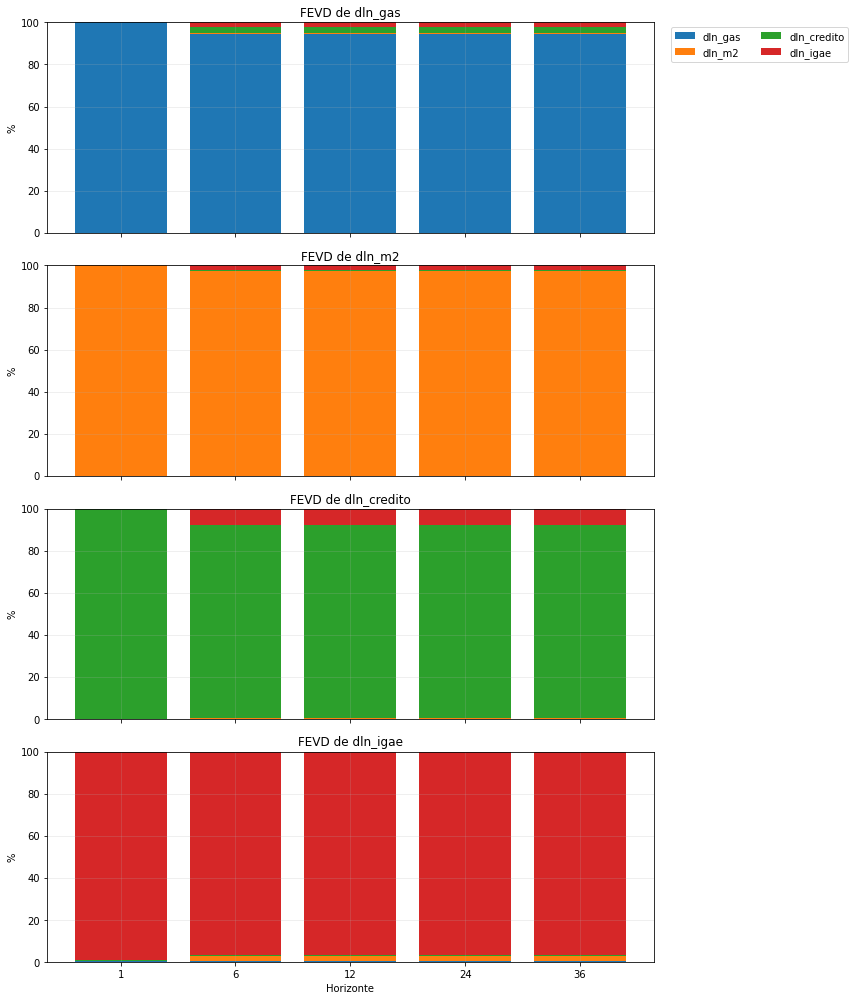

In [32]:
def plot_fevd_bars(fevd, horizons, names):
    k = len(names)
    fig, axes = plt.subplots(k, 1, figsize=(12, 3.5*k), sharex=True)
    x = np.arange(len(horizons))
    for i, ax in enumerate(np.atleast_1d(axes)):
        bottom = np.zeros(len(horizons))
        for j, shock in enumerate(names):
            values = np.array([100 * fevd[h-1, i, j] for h in horizons])
            ax.bar(x, values, bottom=bottom, label=shock)
            bottom += values
        ax.set_title(f'FEVD de {names[i]}')
        ax.set_ylabel('%')
        ax.set_ylim(0, 100)
    axes[-1].set_xticks(x, [str(h) for h in horizons])
    axes[-1].set_xlabel('Horizonte')
    axes[0].legend(ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_fevd_bars(FEVD, HORIZONS, ORDER)

# 6. Identificación estructural

## 6.1 Principios generales

Una vez estimado el VAR reducido, se obtiene la matriz de varianzas y covarianzas de sus innovaciones,

$$
\Sigma_u=E(u_tu_t^{\prime}).
$$

Sin embargo, el VAR reducido únicamente identifica las innovaciones $u_t$, las cuales, en general, se encuentran contemporáneamente correlacionadas. Desde el punto de vista económico, el interés radica en recuperar los **shocks estructurales** $\varepsilon_t$, que por construcción son ortogonales,

$$
E(\varepsilon_t\varepsilon_t^{\prime})=I.
$$

Para ello se plantea la relación

$$
u_t=C_0\varepsilon_t,
$$

donde $C_0$ es la matriz de impacto contemporáneo que describe cómo los shocks estructurales afectan instantáneamente a las variables del sistema.

Combinando las expresiones anteriores se obtiene

$$
\Sigma_u=C_0C_0^{\prime}.
$$

El problema consiste en recuperar la matriz $C_0$ a partir de la matriz observada $\Sigma_u$.

---

## ¿Por qué son necesarias restricciones?

La matriz $\Sigma_u$ es simétrica y únicamente contiene

$$
\frac{K(K+1)}{2}
$$

elementos distintos.

En cambio, la matriz de impacto contemporáneo

$$
C_0
$$

contiene

$$
K^2
$$

parámetros desconocidos.

Como consecuencia,

$$
K^2>
\frac{K(K+1)}{2},
$$

el sistema está subidentificado.

Por tanto, para obtener una identificación exacta es necesario imponer

$$
K^2-\frac{K(K+1)}{2}
=
\frac{K(K-1)}{2}
$$

restricciones adicionales e independientes.

En un sistema con

$$
K=4,
$$

el número mínimo de restricciones es

$$
\frac{4(4-1)}{2}=6.
$$

---

## ¿Dónde se imponen las restricciones?

Dependiendo de la teoría económica utilizada, las restricciones pueden imponerse sobre distintas matrices.

### Restricciones de corto plazo

Las restricciones se imponen directamente sobre la matriz de impacto contemporáneo

$$
C_0.
$$

Por ejemplo,

$$
C_0=
\begin{pmatrix}
* & 0 & 0 & 0\\
* & * & 0 & 0\\
* & * & * & 0\\
* & * & * & *
\end{pmatrix},
$$

donde

- $*$ representa un parámetro libre;
- $0$ representa una restricción impuesta por la teoría económica.

La identificación recursiva de Cholesky constituye un caso particular de este tipo de restricciones.

---

### Restricciones de largo plazo

En este caso las restricciones **no se imponen sobre $C_0$**, sino sobre la matriz de efectos permanentes,

$$
D(1)=\Phi(1)C_0,
$$

donde

$$
\Phi(1)=\sum_{h=0}^{\infty}\Phi_h.
$$

Una estructura posible es

$$
D(1)=
\begin{pmatrix}
* & 0 & 0 & 0\\
* & * & 0 & 0\\
* & * & * & *\\
* & 0 & * & *
\end{pmatrix}.
$$

Aquí, los ceros indican que determinados shocks **no producen efectos permanentes** sobre algunas variables, mientras que los parámetros libres representan efectos de largo plazo permitidos por la teoría económica.

En la notebook, estas restricciones se especifican modificando la matriz correspondiente antes de estimar la identificación estructural.

---

### Restricciones de signo

Las restricciones de signo establecen que la respuesta de una variable ante determinado shock debe ser positiva, negativa o nula.

Estas restricciones pueden imponerse sobre

$$
C_0=\Theta_0,
$$

cuando únicamente interesa el impacto contemporáneo, o bien sobre

$$
\Theta_h=\Phi_hC_0,
$$

cuando se desea controlar el signo de las respuestas durante uno o varios horizontes.

Por ejemplo,

$$
\Theta_h=
\begin{pmatrix}
+ & - & * & *\\
+ & + & * & *\\
* & + & + & *\\
* & * & + & +
\end{pmatrix},
$$

donde

- "$+$" indica una respuesta positiva;
- "$-$" indica una respuesta negativa;
- "$*$" indica ausencia de restricción.

En la notebook, estas restricciones se definen explícitamente dentro de la matriz de signos utilizada por el algoritmo de identificación.

---

## Consecuencia de la identificación

Una vez obtenida una matriz admisible $C_0$, independientemente del método de identificación empleado (Cholesky, restricciones de largo plazo o restricciones de signo), es posible calcular inmediatamente:

- los shocks estructurales;
- las funciones de impulso-respuesta (FIR);
- las respuestas acumuladas;
- la descomposición de la varianza del error de pronóstico (FEVD);
- simulaciones estructurales;
- ejercicios de pronóstico estructural.

> **Observación.** El VAR reducido es exactamente el mismo en todos los casos. Lo único que cambia es la forma en que se identifica la matriz $C_0$. En consecuencia, distintos esquemas de identificación producen diferentes shocks estructurales, diferentes funciones de impulso-respuesta y diferentes descomposiciones de la varianza del error de pronóstico, aunque todos parten del mismo VAR reducido estimado.

### 6.1 Restricciones de largo plazo



In [37]:
def long_run_multiplier(coefs):
    k = coefs.shape[1]
    return np.linalg.inv(np.eye(k) - np.sum(coefs, axis=0))

def identify_long_run_exact(coefs, sigma_u, zero_mask, start=None):
    sigma_u = np.asarray(sigma_u, dtype=float)
    k = sigma_u.shape[0]
    Phi1 = long_run_multiplier(np.asarray(coefs))
    zero_positions = list(zip(*np.where(zero_mask)))
    required = k * (k - 1) // 2

    if len(zero_positions) != required:
        raise ValueError(
            f"Se requieren {required} restricciones; "
            f"la plantilla contiene {len(zero_positions)}."
        )

    tri = np.tril_indices(k)

    def equations(x):
        C = x.reshape(k, k)
        covariance_conditions = (C @ C.T - sigma_u)[tri]
        D1 = Phi1 @ C
        long_run_conditions = np.array(
            [D1[i, j] for i, j in zero_positions]
        )
        return np.r_[covariance_conditions, long_run_conditions]

    if start is None:
        start = np.linalg.cholesky(sigma_u)

    solution = least_squares(
        equations,
        np.asarray(start).reshape(-1),
        method="lm",
        max_nfev=10000,
        xtol=1e-12,
        ftol=1e-12,
        gtol=1e-12
    )

    C = solution.x.reshape(k, k)

    # Normalización de signo.
    for j in range(k):
        if C[j, j] < 0:
            C[:, j] *= -1

    D1 = Phi1 @ C
    max_error = np.max(np.abs(equations(C.reshape(-1))))

    return C, D1, solution.success, max_error, zero_positions

# AQUÍ SE IMPONEN LAS RESTRICCIONES DE LARGO PLAZO.
# Filas: variables de respuesta.
# Columnas: shocks.
# True significa efecto acumulado igual a cero.
LR_ZERO_MASK = np.array([
    [False, True,  True,  True ],
    [False, False, True,  True ],
    [False, False, False, False],
    [False, True,  False, False],
], dtype=bool)

C0_longrun, D1_longrun, lr_success, lr_error, lr_zeros = (
    identify_long_run_exact(
        np.asarray(var_fit.coefs),
        Sigma_u,
        LR_ZERO_MASK,
        start=C0
    )
)

print("Convergencia:", lr_success)
print("Máximo error numérico:", f"{lr_error:.3e}")

print("\nImpacto contemporáneo C0")
display(pd.DataFrame(
    C0_longrun,
    index=ORDER,
    columns=[f"shock_{c}" for c in ORDER]
))

print("\nEfecto acumulado D(1)")
display(pd.DataFrame(
    D1_longrun,
    index=ORDER,
    columns=[f"shock_{c}" for c in ORDER]
))

print("\nRestricciones verificadas")
for i, j in lr_zeros:
    print(f"D(1)[{ORDER[i]}, shock_{ORDER[j]}] = {D1_longrun[i,j]:.3e}")

Convergencia: True
Máximo error numérico: 2.048e-01

Impacto contemporáneo C0


,shock_dln_gas,shock_dln_m2,shock_dln_credito,shock_dln_igae
dln_gas,6.5806,0.3665,-0.4184,-0.2351
dln_m2,-0.2049,2.8127,0.0076,0.2084
dln_credito,0.1444,0.0079,1.5997,0.1371
dln_igae,-0.0832,-0.4082,-0.0783,3.8194



Efecto acumulado D(1)


,shock_dln_gas,shock_dln_m2,shock_dln_credito,shock_dln_igae
dln_gas,4.2901,-0.0050,0.0000,-0.0109
dln_m2,-0.2415,2.6355,0.0007,-0.1941
dln_credito,0.1387,-0.0305,1.7338,0.1216
dln_igae,-0.1055,-0.2048,-0.0096,2.4978



Restricciones verificadas
D(1)[dln_gas, shock_dln_m2] = -5.038e-03
D(1)[dln_gas, shock_dln_credito] = 4.199e-05
D(1)[dln_gas, shock_dln_igae] = -1.093e-02
D(1)[dln_m2, shock_dln_credito] = 7.459e-04
D(1)[dln_m2, shock_dln_igae] = -1.941e-01
D(1)[dln_igae, shock_dln_m2] = -2.048e-01


#### FIR y FEVD con restricciones de largo plazo

Los elementos de \(C_0\) pueden ser distintos de cero porque los ceros se impusieron sobre \(D(1)\), no sobre el impacto contemporáneo.

Las respuestas se obtienen mediante

$$
\Theta_h^{LR}=\Phi_hC_0^{LR},
$$

y la FEVD se calcula a partir de estas FIR estructurales.

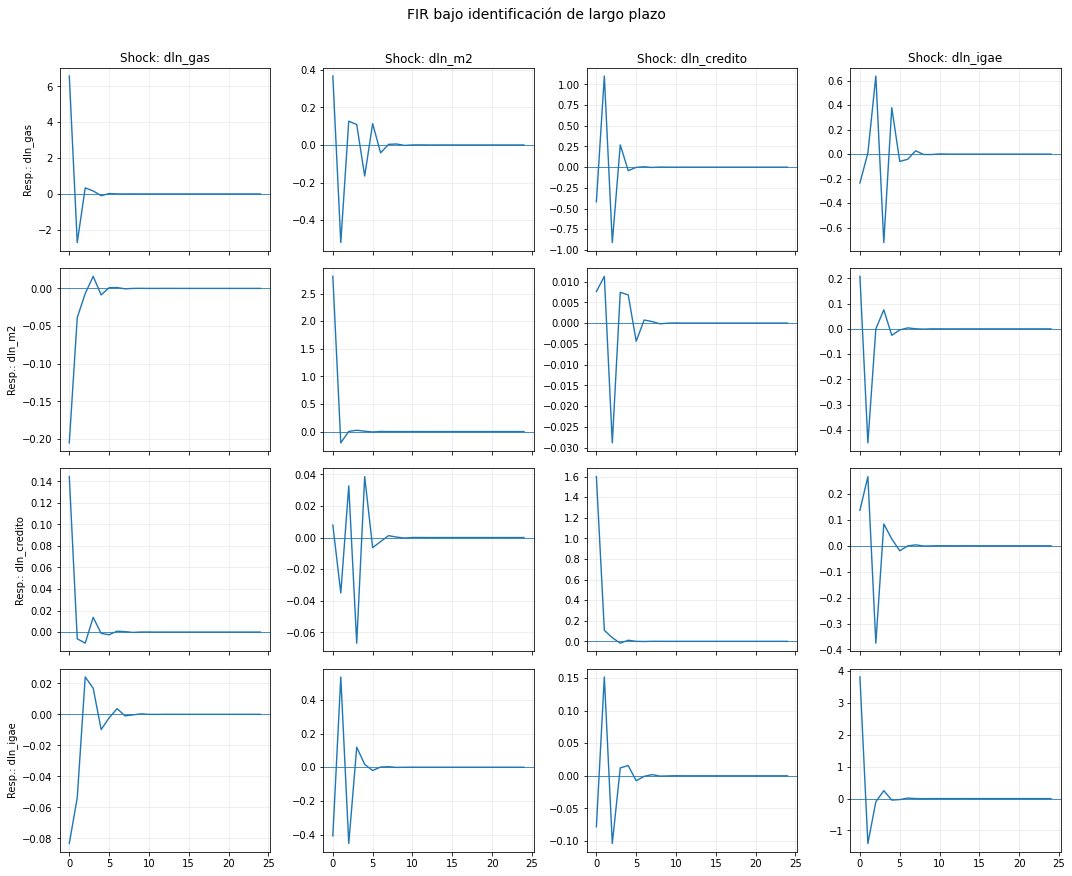

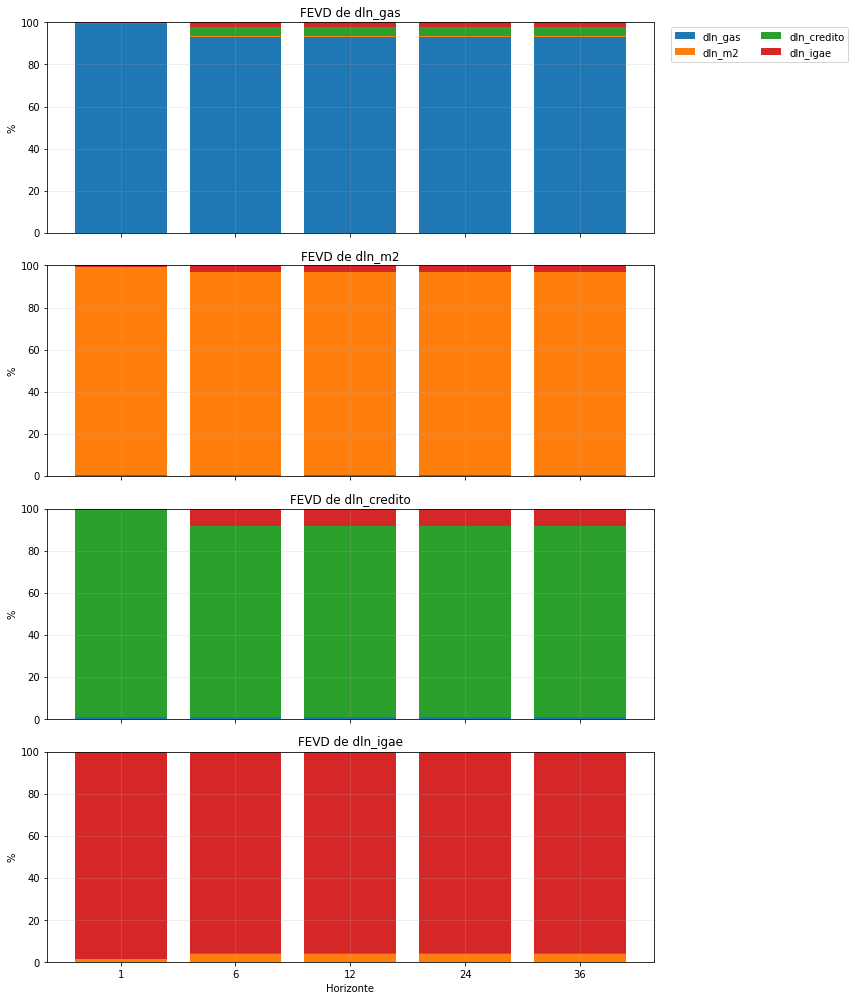

In [35]:
IRF_longrun = structural_irfs(
    np.asarray(var_fit.coefs),
    C0_longrun,
    H
)
FEVD_longrun = compute_fevd(IRF_longrun)

plot_irf_panel(
    IRF_longrun,
    ORDER,
    horizon=24,
    title="FIR bajo identificación de largo plazo"
)

plot_fevd_bars(
    FEVD_longrun,
    horizons=HORIZONS,
    names=ORDER
)

### 6.2 Restricciones de signo

Las restricciones de signo pueden imponerse:

- en \(h=0\), sobre \(C_0=\Theta_0\);
- en varios horizontes, sobre \(\Theta_h=\Phi_hC_0\).

Cada condición se escribe como

```python
(respuesta, shock, horizontes, signo)
```

con `+1` para respuesta no negativa y `-1` para respuesta no positiva.

Estas restricciones suelen producir identificación por conjuntos. Por ello no tienen que sumar exactamente \(K(K-1)/2\): se generan rotaciones ortogonales y se conservan las que satisfacen todas las condiciones.

In [39]:
def random_orthogonal(k, rg):
    Q, R = np.linalg.qr(rg.normal(size=(k, k)))
    signs = np.sign(np.diag(R))
    signs[signs == 0] = 1
    return Q @ np.diag(signs)


def satisfies_signs(irf, restrictions, tolerance=1e-12):
    for response, shock, horizons, sign in restrictions:
        i = ORDER.index(response)
        j = ORDER.index(shock)

        values = irf[np.asarray(horizons), i, j]

        if sign > 0 and not np.all(values >= -tolerance):
            return False

        if sign < 0 and not np.all(values <= tolerance):
            return False

    return True


# ============================================================
# Restricciones de signo
# ============================================================

SIGN_RESTRICTIONS = [
    ("dln_gas", "dln_gas", [0], +1),
    ("dln_m2", "dln_m2", [0, 1, 2], +1),
    ("dln_credito", "dln_m2", [0, 1, 2], +1),
    ("dln_credito", "dln_credito", [0, 1, 2], +1),
]

accepted_irfs = []

MAX_DRAWS = 100000  # Increased from 5000
TARGET_ACCEPTED = 100 # Increased from 50
SIGN_HORIZON = 24

for _ in range(MAX_DRAWS):

    # Rotación ortogonal
    Q = random_orthogonal(len(ORDER), rng)

    # Matriz de impacto candidata:
    # C0(Q) C0(Q)' = Sigma_u
    impact_candidate = C0 @ Q

    # FIR asociadas a la rotación
    irf_candidate = structural_irfs(
        np.asarray(var_fit.coefs),
        impact_candidate,
        SIGN_HORIZON
    )

    # Aceptación si satisface todas las restricciones
    if satisfies_signs(
        irf_candidate,
        SIGN_RESTRICTIONS
    ):
        accepted_irfs.append(irf_candidate)

    if len(accepted_irfs) >= TARGET_ACCEPTED:
        break


print("Rotaciones aceptadas:", len(accepted_irfs))

if not accepted_irfs:
    raise RuntimeError(
        "No se encontraron rotaciones admisibles. "
        "Revise las restricciones."
    )


accepted_irfs_array = np.stack(accepted_irfs)

# Verificación estructural de las rotaciones aceptadas.
# Cada matriz candidata se obtiene como C0 @ Q, con Q ortogonal,
# por lo que preserva C0(Q)C0(Q)' = Sigma_u.
assert accepted_irfs_array.shape[1:] == (SIGN_HORIZON + 1, len(ORDER), len(ORDER))

# Resumen de las FIR
IRF_sign_median = np.median(
    accepted_irfs_array,
    axis=0
)

# Bandas del 95%
IRF_sign_lo = np.quantile(
    accepted_irfs_array,
    0.025,
    axis=0
)

IRF_sign_hi = np.quantile(
    accepted_irfs_array,
    0.975,
    axis=0
)


# ============================================================
# FEVD para cada rotación aceptada
# ============================================================

accepted_fevd = np.stack([
    compute_fevd(draw)
    for draw in accepted_irfs_array
])

# Cada FEVD individual debe sumar uno
fevd_sums = accepted_fevd.sum(axis=-1)

print(
    "Máxima desviación individual respecto de 1:",
    np.max(np.abs(fevd_sums - 1.0))
)


# La media conserva la propiedad de suma igual a uno
FEVD_sign_mean = np.mean(
    accepted_fevd,
    axis=0
)

# Bandas percentiles del 95%
FEVD_sign_lo = np.quantile(
    accepted_fevd,
    0.025,
    axis=0
)

FEVD_sign_hi = np.quantile(
    accepted_fevd,
    0.975,
    axis=0
)

print(
    "Máxima desviación de la FEVD media respecto de 1:",
    np.max(
        np.abs(
            FEVD_sign_mean.sum(axis=-1) - 1.0
        )
    )
)


display(
    pd.DataFrame(
        SIGN_RESTRICTIONS,
        columns=[
            "respuesta",
            "shock",
            "horizontes",
            "signo"
        ]
    )
)


Rotaciones aceptadas: 2
Máxima desviación individual respecto de 1: 2.220446049250313e-16
Máxima desviación de la FEVD media respecto de 1: 2.220446049250313e-16


,respuesta,shock,horizontes,signo
0,dln_gas,dln_gas,[0],1
1,dln_m2,dln_m2,"[0, 1, 2]",1
2,dln_credito,dln_m2,"[0, 1, 2]",1
3,dln_credito,dln_credito,"[0, 1, 2]",1


#### FIR y FEVD con restricciones de signo

Se reporta la mediana de las respuestas admisibles y los percentiles 2.5 y 97.5 como región central del 95%. Estas bandas representan dispersión entre rotaciones admisibles, no incertidumbre bootstrap.

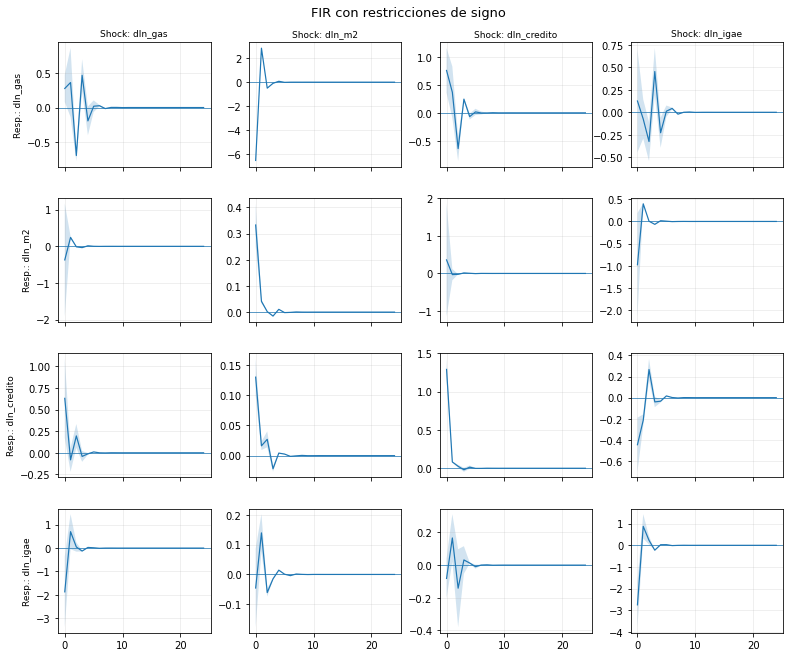

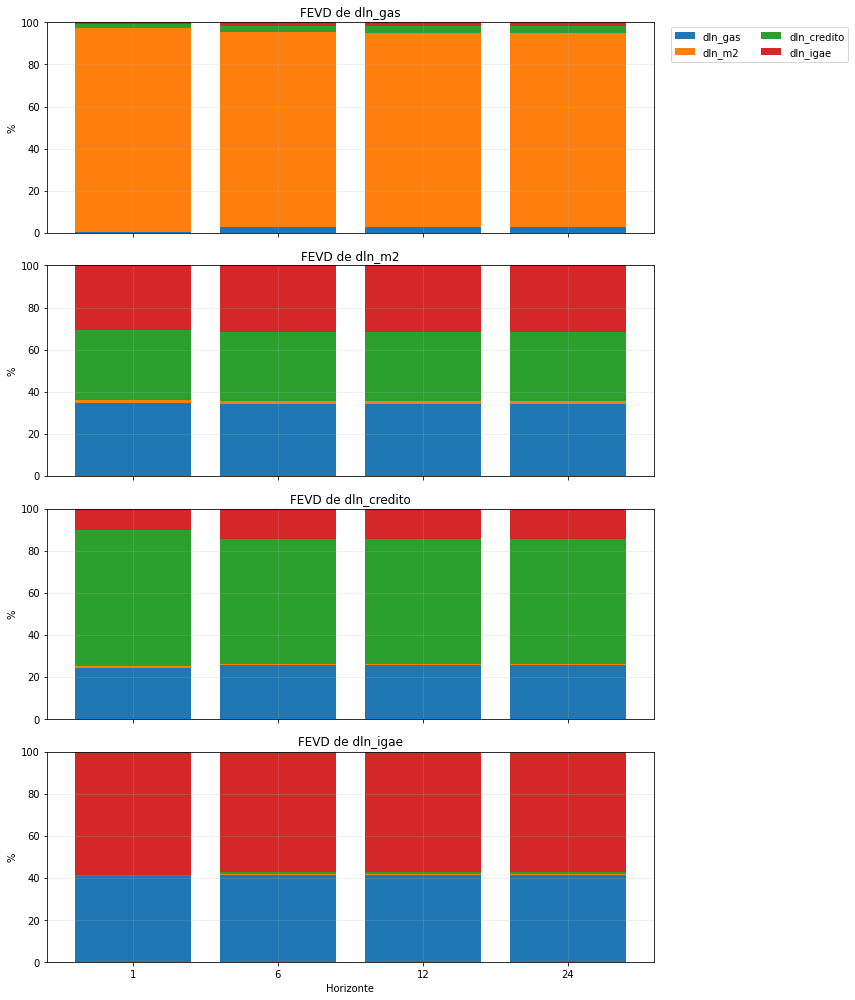

In [40]:
plot_irf_bands_panel(
    IRF_sign_median,
    IRF_sign_lo,
    IRF_sign_hi,
    ORDER,
    horizon=SIGN_HORIZON,
    title="FIR con restricciones de signo"
)

plot_fevd_bars(
    FEVD_sign_mean,
    horizons=[1, 6, 12, 24],
    names=ORDER
)

### 6.3 Comparación entre identificaciones

No existe un estadístico universal que elija automáticamente entre Cholesky, largo plazo y signos. La decisión debe apoyarse en teoría económica, instituciones, plausibilidad de las restricciones y robustez de los resultados.

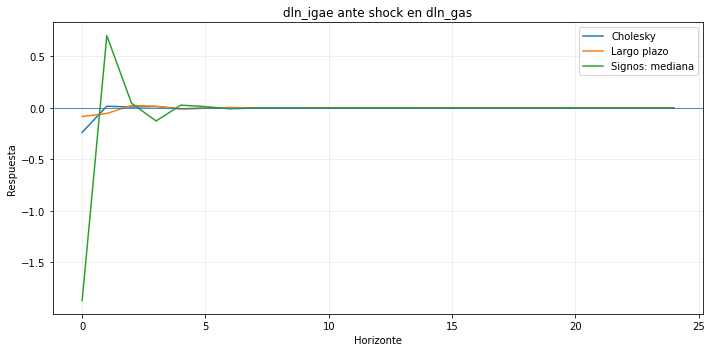

In [41]:
# ============================================================
# Comparación de FIR entre métodos de identificación
# ============================================================

# Este bloque reconstruye las FIR de largo plazo si la matriz
# C0_longrun ya fue estimada, pero la celda de FIR/FEVD no se
# ejecutó o el kernel perdió esa variable.
if "IRF_longrun" not in globals():
    if "C0_longrun" not in globals():
        # Reconstrucción completa de la identificación de largo plazo.
        C0_longrun, D1_longrun, lr_success, lr_error, lr_zeros = (
            identify_long_run_exact(
                np.asarray(var_fit.coefs),
                Sigma_u,
                LR_ZERO_MASK,
                start=C0
            )
        )

        if (not lr_success) or (lr_error > 1e-8):
            raise RuntimeError(
                "La identificación de largo plazo no convergió "
                f"adecuadamente. Error máximo: {lr_error:.3e}"
            )

    IRF_longrun = structural_irfs(
        np.asarray(var_fit.coefs),
        C0_longrun,
        H
    )
    FEVD_longrun = compute_fevd(IRF_longrun)

required_objects = {
    "IRF": "FIR bajo Cholesky",
    "IRF_longrun": "FIR bajo restricciones de largo plazo",
    "IRF_sign_median": "FIR mediana bajo restricciones de signo",
    "ORDER": "orden de las variables",
}

missing = [name for name in required_objects if name not in globals()]

if missing:
    detail = "\n".join(
        f"- {name}: {required_objects[name]}"
        for name in missing
    )
    raise RuntimeError(
        "Faltan resultados necesarios para comparar las identificaciones:\n"
        f"{detail}\n\n"
        "Ejecute la notebook desde el comienzo mediante "
        "'Restart & Run All'."
    )

response = "dln_igae"
shock = "dln_gas"

if response not in ORDER:
    raise ValueError(f"La respuesta '{response}' no pertenece a ORDER.")
if shock not in ORDER:
    raise ValueError(f"El shock '{shock}' no pertenece a ORDER.")

i = ORDER.index(response)
j = ORDER.index(shock)

comparison_horizon = min(
    24,
    IRF.shape[0] - 1,
    IRF_longrun.shape[0] - 1,
    IRF_sign_median.shape[0] - 1
)

horizons_comparison = np.arange(comparison_horizon + 1)

plt.figure(figsize=(10, 5))
plt.plot(
    horizons_comparison,
    IRF[:comparison_horizon + 1, i, j],
    label="Cholesky"
)
plt.plot(
    horizons_comparison,
    IRF_longrun[:comparison_horizon + 1, i, j],
    label="Largo plazo"
)
plt.plot(
    horizons_comparison,
    IRF_sign_median[:comparison_horizon + 1, i, j],
    label="Signos: mediana"
)

plt.axhline(0, lw=0.8)
plt.xlabel("Horizonte")
plt.ylabel("Respuesta")
plt.title(f"{response} ante shock en {shock}")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Pronóstico con modelos VAR

### 7.1 Entrenamiento y prueba

La muestra se divide cronológicamente:

- entrenamiento: primeras \(T-H\) observaciones;
- prueba: últimas \(H\) observaciones.

Se reservan 24 meses para prueba y se reportan los porcentajes exactos.

### 7.2 Dinámico, estático y rolling

- **Dinámico:** el VAR se estima una vez; los pronósticos multihorizonte utilizan sus propios valores pronosticados como rezagos.
- **Estático de un paso:** usa la información observada disponible hasta \(t-1\).
- **Rolling/recursive:** describe cómo se actualiza la muestra de estimación. Aquí se usa una ventana expansiva y un pronóstico estático de un paso.

Por tanto, “estático” y “rolling” no son exactamente sinónimos.

### 7.3 Métricas

$$
RMSE=\sqrt{\frac{1}{T}\sum(\widehat y_t-y_t)^2},
\qquad
MAE=\frac{1}{T}\sum|\widehat y_t-y_t|.
$$

$$
U_1=
\frac{
\sqrt{\frac{1}{T}\sum(\widehat y_t-y_t)^2}
}{
\sqrt{\frac{1}{T}\sum\widehat y_t^2}
+
\sqrt{\frac{1}{T}\sum y_t^2}
}.
$$

$$
U_2=
\frac{
\sqrt{\frac{1}{T}\sum(\widehat y_t-y_t)^2}
}{
\sqrt{\frac{1}{T}\sum(y_t-y_{t-1})^2}
}.
$$

- \(U_2<1\): el VAR supera al benchmark ingenuo;
- \(U_2=1\): desempeño equivalente;
- \(U_2>1\): el benchmark es superior.

In [42]:
TEST_SIZE = 24

train = y.iloc[:-TEST_SIZE].copy()
test = y.iloc[-TEST_SIZE:].copy()

split_summary = pd.DataFrame({
    "segmento": ["Entrenamiento", "Prueba"],
    "observaciones": [len(train), len(test)],
    "porcentaje": [
        100 * len(train) / len(y),
        100 * len(test) / len(y)
    ],
    "inicio": [train.index.min(), test.index.min()],
    "fin": [train.index.max(), test.index.max()]
})
display(split_summary)

# Dinámico multihorizonte.
fit_train = VAR(train).fit(VAR_LAGS, trend="c")
dyn_point, dyn_lower, dyn_upper = fit_train.forecast_interval(
    train.to_numpy()[-VAR_LAGS:],
    steps=TEST_SIZE,
    alpha=0.05
)

pred_dynamic = pd.DataFrame(dyn_point, index=test.index, columns=ORDER)
pred_dynamic_lower = pd.DataFrame(dyn_lower, index=test.index, columns=ORDER)
pred_dynamic_upper = pd.DataFrame(dyn_upper, index=test.index, columns=ORDER)

# Estático de un paso con ventana expansiva.
rolling_point_rows = []
rolling_lower_rows = []
rolling_upper_rows = []
history = train.copy()

for date in test.index:
    fit_roll = VAR(history).fit(VAR_LAGS, trend="c")
    p1, l1, u1 = fit_roll.forecast_interval(
        history.to_numpy()[-VAR_LAGS:],
        steps=1,
        alpha=0.05
    )
    rolling_point_rows.append(p1[0])
    rolling_lower_rows.append(l1[0])
    rolling_upper_rows.append(u1[0])
    history = pd.concat([history, test.loc[[date]]])

pred_rolling = pd.DataFrame(
    rolling_point_rows, index=test.index, columns=ORDER
)
pred_rolling_lower = pd.DataFrame(
    rolling_lower_rows, index=test.index, columns=ORDER
)
pred_rolling_upper = pd.DataFrame(
    rolling_upper_rows, index=test.index, columns=ORDER
)

def forecast_metrics(actual, forecast, benchmark):
    error = forecast - actual
    rmse = np.sqrt((error ** 2).mean())
    mae = error.abs().mean()

    u1 = rmse / (
        np.sqrt((forecast ** 2).mean())
        + np.sqrt((actual ** 2).mean())
    )

    rmse_benchmark = np.sqrt(
        ((benchmark - actual) ** 2).mean()
    )
    u2 = rmse / rmse_benchmark

    return pd.DataFrame({
        "RMSE": rmse,
        "MAE": mae,
        "Theil U1": u1,
        "Theil U2": u2
    })

naive = test.shift(1)
naive.iloc[0] = train.iloc[-1]

metrics = pd.concat(
    {
        "Dinámico": forecast_metrics(
            test, pred_dynamic, naive
        ),
        "Estático rolling": forecast_metrics(
            test, pred_rolling, naive
        )
    },
    names=["método", "variable"]
)

display(metrics)

,segmento,observaciones,porcentaje,inicio,fin
0,Entrenamiento,167,87.4346,2009-02-01,2022-12-01
1,Prueba,24,12.5654,2023-01-01,2024-12-01


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

RMSE    MAE  Theil U1  Theil U2
método           variable                                      
Dinámico         dln_gas      7.8033 3.4536    0.9362    0.6572
                 dln_m2       4.4493 1.6836    0.9200    0.6005
                 dln_credito  4.7217 1.5075    0.9940    0.7157
                 dln_igae     6.0942 2.7619    0.8560    0.5818
Estático rolling dln_gas     17.4361 9.0892    0.7312    1.4684
                 dln_m2       6.8881 3.3835    0.7033    0.9296
                 dln_credito 10.2372 3.8453    0.7402    1.5517
                 dln_igae    17.4700 8.3002    0.7740    1.6679

### 7.4 Pronósticos fuera de muestra en diferencias

Se muestran observado, pronóstico puntual y límites de confianza del 95% para ambos métodos.

In [43]:
dynamic_differences_table = pd.concat(
    {
        "observado": test,
        "pronóstico": pred_dynamic,
        "límite inferior 95%": pred_dynamic_lower,
        "límite superior 95%": pred_dynamic_upper
    },
    axis=1
)

rolling_differences_table = pd.concat(
    {
        "observado": test,
        "pronóstico": pred_rolling,
        "límite inferior 95%": pred_rolling_lower,
        "límite superior 95%": pred_rolling_upper
    },
    axis=1
)

print("Dinámico: diferencias logarítmicas")
display(dynamic_differences_table)

print("Estático rolling: diferencias logarítmicas")
display(rolling_differences_table)

Dinámico: diferencias logarítmicas


observado                               pronóstico          \
             dln_gas   dln_m2 dln_credito dln_igae    dln_gas  dln_m2   
Date                                                                    
2023-01-01  -19.9773  -0.2947      0.0353  -0.6904    -0.3092 -1.9522   
2023-02-01    0.0000  -0.5248      0.0069  -0.5417     0.5407 -0.4896   
2023-03-01    0.0000  -2.3037     -0.0268   0.7661     1.5074  0.3289   
2023-04-01    0.0000 -14.1558     -0.1219  -0.8021    -1.4286 -0.0580   
2023-05-01    0.0000  16.1155     -1.5247   0.6153     0.9733 -0.1254   
2023-06-01    0.0000   0.2322     -0.7376  -0.5477     0.0218  0.0021   
2023-07-01    0.0000   0.8272     -0.1344   0.3051     0.1901 -0.0174   
2023-08-01    0.0000  -0.5091     -0.5900   0.3278     0.0847 -0.0234   
2023-09-01    0.0000  -0.4066    -15.0696   0.0746     0.2073 -0.0264   
2023-10-01    0.0000   0.9349      0.0000   0.6897     0.1178 -0.0209   
2023-11-01    0.0000   0.2917      0.0000   0.2571     0.1542 -0.0219   
2023-12-01    0.0000   0.5750      0.0000  -1.4107     0.1332 -0.0219   
2024-01-01    0.0000  -0.0848      0.0000   0.4843     0.1443 -0.0222   
2024-02-01    0.0000   0.0744      0.0000  -0.4034     0.1361 -0.0217   
2024-03-01    0.0000   0.1046      0.0000 -16.8754     0.1391 -0.0218   
2024-04-01    0.0000   0.1855      0.0000  17.4041     0.1366 -0.0218   
2024-05-01    0.0000   0.0551     17.4535   0.0302     0.1375 -0.0218   
2024-06-01   18.8304   0.2445      0.1325  -0.2564     0.1365 -0.0217   
2024-07-01  -18.8304   0.2796     -0.0197  -0.1660     0.1367 -0.0217   
2024-08-01    0.0000   0.0117      0.0270  -0.5058     0.1364 -0.0217   
2024-09-01    0.0000   0.1391      0.0299 -16.5063     0.1364 -0.0217   
2024-10-01    0.0000   0.2437     -0.0530   0.0000     0.1363 -0.0217   
2024-11-01    0.0000   0.1732      0.0210   0.0000     0.1363 -0.0217   
2024-12-01   19.0961  -0.1665     -0.0042   0.0000     0.1362 -0.0217   

                                límite inferior 95%                      \
           dln_credito dln_igae             dln_gas  dln_m2 dln_credito   
Date                                                                      
2023-01-01      0.1039  -5.2618            -13.4443 -7.0004     -0.0667   
2023-02-01     -0.0785   0.1145            -13.9745 -5.6653     -0.2746   
2023-03-01      0.0119  -0.6502            -13.1879 -4.8535     -0.2010   
2023-04-01     -0.0067   1.0323            -16.1257 -5.2478     -0.2229   
2023-05-01     -0.0016  -0.6178            -13.7421 -5.3162     -0.2211   
2023-06-01     -0.0150   0.1342            -14.6977 -5.1889     -0.2357   
2023-07-01     -0.0074  -0.1289            -14.5326 -5.2086     -0.2289   
2023-08-01     -0.0111   0.0506            -14.6385 -5.2146     -0.2330   
2023-09-01     -0.0103  -0.0817            -14.5164 -5.2176     -0.2323   
2023-10-01     -0.0117  -0.0110            -14.6060 -5.2121     -0.2338   
2023-11-01     -0.0112  -0.0414            -14.5697 -5.2131     -0.2334   
2023-12-01     -0.0117  -0.0221            -14.5907 -5.2130     -0.2339   
2024-01-01     -0.0117  -0.0344            -14.5797 -5.2134     -0.2339   
2024-02-01     -0.0119  -0.0271            -14.5879 -5.2129     -0.2341   
2024-03-01     -0.0118  -0.0303            -14.5849 -5.2130     -0.2341   
2024-04-01     -0.0119  -0.0282            -14.5874 -5.2129     -0.2342   
2024-05-01     -0.0119  -0.0293            -14.5865 -5.2129     -0.2342   
2024-06-01     -0.0120  -0.0285            -14.5875 -5.2129     -0.2342   
2024-07-01     -0.0120  -0.0288            -14.5873 -5.2129     -0.2342   
2024-08-01     -0.0120  -0.0286            -14.5876 -5.2129     -0.2342   
2024-09-01     -0.0120  -0.0287            -14.5876 -5.2129     -0.2343   
2024-10-01     -0.0120  -0.0286            -14.5877 -5.2129     -0.2343   
2024-11-01     -0.0120  -0.0286            -14.5877 -5.2129     -0.2343   
2024-12-01     -0.0120  -0.0286            -14.5878 -5.2129     -0.2343   

             

Estático rolling: diferencias logarítmicas


observado                               pronóstico          \
             dln_gas   dln_m2 dln_credito dln_igae    dln_gas  dln_m2   
Date                                                                    
2023-01-01  -19.9773  -0.2947      0.0353  -0.6904    -0.3092 -1.9522   
2023-02-01    0.0000  -0.5248      0.0069  -0.5417    11.6725 -0.8868   
2023-03-01    0.0000  -2.3037     -0.0268   0.7661     3.5592  0.4026   
2023-04-01    0.0000 -14.1558     -0.1219  -0.8021     0.5571 -0.2019   
2023-05-01    0.0000  16.1155     -1.5247   0.6153     2.5583 -1.0989   
2023-06-01    0.0000   0.2322     -0.7376  -0.5477    -3.0846  0.6763   
2023-07-01    0.0000   0.8272     -0.1344   0.3051   -15.2368  1.6614   
2023-08-01    0.0000  -0.5091     -0.5900   0.3278    -4.6259 -0.2352   
2023-09-01    0.0000  -0.4066    -15.0696   0.0746     0.5258  1.0136   
2023-10-01    0.0000   0.9349      0.0000   0.6897    21.7649 24.8351   
2023-11-01    0.0000   0.2917      0.0000   0.2571   -71.8095  6.5877   
2023-12-01    0.0000   0.5750      0.0000  -1.4107     0.0106 -0.1236   
2024-01-01    0.0000  -0.0848      0.0000   0.4843     0.0589  0.1334   
2024-02-01    0.0000   0.0744      0.0000  -0.4034    -0.0955  0.0274   
2024-03-01    0.0000   0.1046      0.0000 -16.8754     0.0617  0.0015   
2024-04-01    0.0000   0.1855      0.0000  17.4041     1.2575  2.5945   
2024-05-01    0.0000   0.0551     17.4535   0.0302    -2.3358 -1.2928   
2024-06-01   18.8304   0.2445      0.1325  -0.2564     1.5082 -2.8684   
2024-07-01  -18.8304   0.2796     -0.0197  -0.1660    -6.8904 -0.9988   
2024-08-01    0.0000   0.0117      0.0270  -0.5058     6.0667  0.0814   
2024-09-01    0.0000   0.1391      0.0299 -16.5063     2.3535  0.2245   
2024-10-01    0.0000   0.2437     -0.0530   0.0000     0.5486  2.1165   
2024-11-01    0.0000   0.1732      0.0210   0.0000    -1.9464  0.9266   
2024-12-01   19.0961  -0.1665     -0.0042   0.0000     0.0156 -0.0221   

                                límite inferior 95%                      \
           dln_credito dln_igae             dln_gas  dln_m2 dln_credito   
Date                                                                      
2023-01-01      0.1039  -5.2618            -13.4443 -7.0004     -0.0667   
2023-02-01     -0.0777  -1.9781             -1.7085 -5.9243     -0.2481   
2023-03-01      0.0086   0.5319             -9.8794 -4.6192     -0.1617   
2023-04-01     -0.0161  -0.8433            -12.8499 -5.2244     -0.1859   
2023-05-01     -0.0845  -2.8393            -10.8069 -6.5475     -0.2546   
2023-06-01     -0.6277  -5.0223            -16.4132 -5.2741     -0.8924   
2023-07-01     -0.6340   3.4097            -28.5269 -4.2707     -0.8981   
2023-08-01     -0.0246   3.7842            -17.9592 -6.1496     -0.2923   
2023-09-01     -0.3657  -2.8666            -12.7828 -4.8828     -0.6443   
2023-10-01    -43.5507 -70.3060              8.4964 18.9529    -45.7078   
2023-11-01     -9.4605  37.4067            -85.0440  0.7068    -11.7557   
2023-12-01     -0.1131  -0.2546            -13.2650 -5.9883     -2.4096   
2024-01-01     -0.1025   0.5433            -13.1771 -5.7147     -2.3922   
2024-02-01     -0.1038  -0.0523            -13.2923 -5.8035     -2.3868   
2024-03-01     -0.1100   0.0924            -13.0962 -5.8122     -2.3862   
2024-04-01     -0.0724   6.3894            -11.8620 -3.2023     -2.3420   
2024-05-01     -0.0446  -4.9883            -15.4182 -7.0825     -2.3076   
2024-06-01     -0.7270  -3.6910            -11.5403 -8.6443     -4.0189   
2024-07-01      0.2058  -1.7501            -20.0031 -6.7655     -3.0776   
2024-08-01     -0.0438  -0.2215             -7.0583 -5.6701     -3.3179   
2024-09-01      0.0277   1.1589            -10.7631 -5.5106     -3.2370   
2024-10-01     -1.1407   7.0684            -12.5352 -3.6024     -4.3962   
2024-11-01      1.4240   2.6045            -14.9937 -4.7822     -1.8259   
2024-12-01     -0.0171  -0.1353            -12.9979 -5.7159     -3.2637   

             

### 7.5 Pronósticos fuera de muestra en niveles

Para el pronóstico dinámico,

$$
\widehat x_{T+h}
=
x_T\exp\left(\sum_{s=1}^{h}\widehat y_{T+s}\right).
$$

Para el pronóstico estático de un paso, cada nivel usa el nivel observado de \(t-1\). Los límites en niveles son aproximados porque se transforman acumulativamente los límites de las diferencias.

In [44]:
LEVEL_COLUMNS = [name.replace("dln_", "") for name in ORDER]

def reconstruct_dynamic_levels(
    last_levels, point, lower, upper
):
    last_logs = np.log(last_levels[LEVEL_COLUMNS])
    last_logs.index = ORDER

    point_levels = np.exp(
        point.cumsum().add(last_logs, axis="columns")
    )
    lower_levels = np.exp(
        lower.cumsum().add(last_logs, axis="columns")
    )
    upper_levels = np.exp(
        upper.cumsum().add(last_logs, axis="columns")
    )

    point_levels.columns = LEVEL_COLUMNS
    lower_levels.columns = LEVEL_COLUMNS
    upper_levels.columns = LEVEL_COLUMNS

    return point_levels, lower_levels, upper_levels

last_train_levels = data.loc[train.index[-1]]

dynamic_levels, dynamic_levels_lower, dynamic_levels_upper = (
    reconstruct_dynamic_levels(
        last_train_levels,
        pred_dynamic,
        pred_dynamic_lower,
        pred_dynamic_upper
    )
)

rolling_levels = pd.DataFrame(
    index=test.index, columns=LEVEL_COLUMNS, dtype=float
)
rolling_levels_lower = rolling_levels.copy()
rolling_levels_upper = rolling_levels.copy()

for date in test.index:
    previous_date = data.index[data.index.get_loc(date) - 1]
    previous_levels = data.loc[previous_date, LEVEL_COLUMNS]

    rolling_levels.loc[date] = (
        previous_levels.to_numpy()
        * np.exp(pred_rolling.loc[date].to_numpy())
    )
    rolling_levels_lower.loc[date] = (
        previous_levels.to_numpy()
        * np.exp(pred_rolling_lower.loc[date].to_numpy())
    )
    rolling_levels_upper.loc[date] = (
        previous_levels.to_numpy()
        * np.exp(pred_rolling_upper.loc[date].to_numpy())
    )

actual_levels = data.loc[test.index, LEVEL_COLUMNS]

dynamic_levels_table = pd.concat(
    {
        "observado": actual_levels,
        "pronóstico": dynamic_levels,
        "límite inferior 95%": dynamic_levels_lower,
        "límite superior 95%": dynamic_levels_upper
    },
    axis=1
)

rolling_levels_table = pd.concat(
    {
        "observado": actual_levels,
        "pronóstico": rolling_levels,
        "límite inferior 95%": rolling_levels_lower,
        "límite superior 95%": rolling_levels_upper
    },
    axis=1
)

print("Dinámico fuera de muestra en niveles")
display(dynamic_levels_table)

print("Estático rolling fuera de muestra en niveles")
display(rolling_levels_table)

Dinámico fuera de muestra en niveles


observado                       pronóstico                        \
                 gas     m2 credito   igae        gas     m2 credito   igae   
Date                                                                          
2023-01-01    0.0000 0.0217  0.0800 0.0257     0.3481 0.0039  0.0857 0.0003   
2023-02-01    0.0000 0.0128  0.0806 0.0149     0.5978 0.0024  0.0793 0.0003   
2023-03-01    0.0000 0.0013  0.0785 0.0321     2.6990 0.0033  0.0802 0.0002   
2023-04-01    0.0000 0.0000  0.0695 0.0144     0.6468 0.0031  0.0797 0.0004   
2023-05-01    0.0000 0.0089  0.0151 0.0267     1.7118 0.0028  0.0795 0.0002   
2023-06-01    0.0000 0.0115  0.0072 0.0154     1.7495 0.0028  0.0784 0.0003   
2023-07-01    0.0000 0.0263  0.0063 0.0209     2.1157 0.0027  0.0778 0.0002   
2023-08-01    0.0000 0.0157  0.0035 0.0290     2.3027 0.0027  0.0769 0.0002   
2023-09-01    0.0000 0.0104  0.0000 0.0313     2.8331 0.0026  0.0761 0.0002   
2023-10-01    0.0000 0.0261  0.0000 0.0623     3.1872 0.0025  0.0752 0.0002   
2023-11-01    0.0000 0.0360  0.0000 0.0806     3.7184 0.0025  0.0744 0.0002   
2023-12-01    0.0000 0.0624  0.0000 0.0197     4.2484 0.0024  0.0735 0.0002   
2024-01-01    0.0000 0.0579  0.0000 0.0319     4.9078 0.0024  0.0727 0.0002   
2024-02-01    0.0000 0.0636  0.0000 0.0213     5.6234 0.0023  0.0718 0.0002   
2024-03-01    0.0000 0.0707  0.0000 0.0000     6.4624 0.0023  0.0710 0.0002   
2024-04-01    0.0000 0.0826  0.0000 0.0362     7.4083 0.0022  0.0701 0.0002   
2024-05-01    0.0000 0.0898  0.0380 0.0373     8.5004 0.0022  0.0693 0.0002   
2024-06-01    0.1506 0.1131  0.0434 0.0289     9.7437 0.0021  0.0685 0.0002   
2024-07-01    0.0000 0.1463  0.0426 0.0244    11.1712 0.0021  0.0677 0.0002   
2024-08-01    0.0000 0.1500  0.0437 0.0147    12.8034 0.0020  0.0669 0.0002   
2024-09-01    0.0000 0.1732  0.0450 0.0000    14.6746 0.0020  0.0661 0.0002   
2024-10-01    0.0000 0.2155  0.0427 0.0000    16.8169 0.0020  0.0653 0.0002   
2024-11-01    0.0000 0.2628  0.0436 0.0000    19.2717 0.0019  0.0645 0.0002   
2024-12-01    0.1965 0.2300  0.0434 0.0000    22.0836 0.0019  0.0637 0.0001   

           límite inferior 95%                        \
                           gas     m2 credito   igae   
Date                                                   
2023-01-01              0.0000 0.0000  0.0723 0.0000   
2023-02-01              0.0000 0.0000  0.0549 0.0000   
2023-03-01              0.0000 0.0000  0.0449 0.0000   
2023-04-01              0.0000 0.0000  0.0359 0.0000   
2023-05-01              0.0000 0.0000  0.0288 0.0000   
2023-06-01              0.0000 0.0000  0.0228 0.0000   
2023-07-01              0.0000 0.0000  0.0181 0.0000   
2023-08-01              0.0000 0.0000  0.0143 0.0000   
2023-09-01              0.0000 0.0000  0.0114 0.0000   
2023-10-01              0.0000 0.0000  0.0090 0.0000   
2023-11-01              0.0000 0.0000  0.0071 0.0000   
2023-12-01              0.0000 0.0000  0.0056 0.0000   
2024-01-01              0.0000 0.0000  0.0045 0.0000   
2024-02-01              0.0000 0.0000  0.0035 0.0000   
2024-03-01              0.0000 0.0000  0.0028 0.0000   
2024-04-01              0.0000 0.0000  0.0022 0.0000   
2024-05-01              0.0000 0.0000  0.0017 0.0000   
2024-06-01              0.0000 0.0000  0.0014 0.0000   
2024-07-01              0.0000 0.0000  0.0011 0.0000   
2024-08-01              0.0000 0.0000  0.0009 0.0000   
2024-09-01              0.0000 0.0000  0.0007 0.0000   
2024-10-01              0.0000 0.0000  0.0005 0.0000   
2024-11-01              0.0000 0.0000  0.0004 0.0000   
2024-12-01              0.0000 0.0000  0.0003 0.0000   

                                          límite superior 95%  \
                                                          gas   
Date                                                            
2023-01-01                                       176,293.8171   
2023-02-01                               609,485,829,452.7074   
2023-03-01                     6,632,60

Estático rolling fuera de muestra en niveles


observado                       pronóstico                   \
                 gas     m2 credito   igae        gas               m2   
Date                                                                     
2023-01-01    0.0000 0.0217  0.0800 0.0257     0.3481           0.0039   
2023-02-01    0.0000 0.0128  0.0806 0.0149     0.0001           0.0089   
2023-03-01    0.0000 0.0013  0.0785 0.0321     0.0000           0.0192   
2023-04-01    0.0000 0.0000  0.0695 0.0144     0.0000           0.0010   
2023-05-01    0.0000 0.0089  0.0151 0.0267     0.0000           0.0000   
2023-06-01    0.0000 0.0115  0.0072 0.0154     0.0000           0.0176   
2023-07-01    0.0000 0.0263  0.0063 0.0209     0.0000           0.0604   
2023-08-01    0.0000 0.0157  0.0035 0.0290     0.0000           0.0207   
2023-09-01    0.0000 0.0104  0.0000 0.0313     0.0000           0.0434   
2023-10-01    0.0000 0.0261  0.0000 0.0623     2.8339 637,171,241.4253   
2023-11-01    0.0000 0.0360  0.0000 0.0806     0.0000          18.9285   
2023-12-01    0.0000 0.0624  0.0000 0.0197     0.0000           0.0318   
2024-01-01    0.0000 0.0579  0.0000 0.0319     0.0000           0.0713   
2024-02-01    0.0000 0.0636  0.0000 0.0213     0.0000           0.0596   
2024-03-01    0.0000 0.0707  0.0000 0.0000     0.0000           0.0637   
2024-04-01    0.0000 0.0826  0.0000 0.0362     0.0000           0.9473   
2024-05-01    0.0000 0.0898  0.0380 0.0373     0.0000           0.0227   
2024-06-01    0.1506 0.1131  0.0434 0.0289     0.0000           0.0051   
2024-07-01    0.0000 0.1463  0.0426 0.0244     0.0002           0.0416   
2024-08-01    0.0000 0.1500  0.0437 0.0147     0.0000           0.1587   
2024-09-01    0.0000 0.1732  0.0450 0.0000     0.0000           0.1878   
2024-10-01    0.0000 0.2155  0.0427 0.0000     0.0000           1.4380   
2024-11-01    0.0000 0.2628  0.0436 0.0000     0.0000           0.5443   
2024-12-01    0.1965 0.2300  0.0434 0.0000     0.0000           0.2570   

                                              límite inferior 95%  \
           credito                       igae                 gas   
Date                                                                
2023-01-01  0.0857                     0.0003              0.0000   
2023-02-01  0.0741                     0.0036              0.0000   
2023-03-01  0.0813                     0.0254              0.0000   
2023-04-01  0.0772                     0.0138              0.0000   
2023-05-01  0.0638                     0.0008              0.0000   
2023-06-01  0.0081                     0.0002              0.0000   
2023-07-01  0.0038                     0.4664              0.0000   
2023-08-01  0.0062                     0.9204              0.0000   
2023-09-01  0.0024                     0.0017              0.0000   
2023-10-01  0.0000                     0.0000              0.0000   
2023-11-01  0.0000 1,097,257,704,122,649.3750              0.0000   
2023-12-01  0.0000                     0.0625              0.0000   
2024-01-01  0.0000                     0.0339              0.0000   
2024-02-01  0.0000                     0.0303              0.0000   
2024-03-01  0.0000                     0.0234              0.0000   
2024-04-01  0.0000                     0.0000              0.0000   
2024-05-01  0.0000                     0.0002              0.0000   
2024-06-01  0.0184                     0.0009              0.0000   
2024-07-01  0.0533                     0.0050              0.0000   
2024-08-01  0.0407                     0.0196              0.0000   
2024-09-01  0.0449                     0.0470              0.0000   
2024-10-01  0.0144                     0.0000              0.0000   
2024-11-01  0.1775                     0.0000              0.0000   
2024-12-01  0.0429                     0.0000              0.0000   

                                                         límite superior 95%  \
                       m2 credito                   igae            

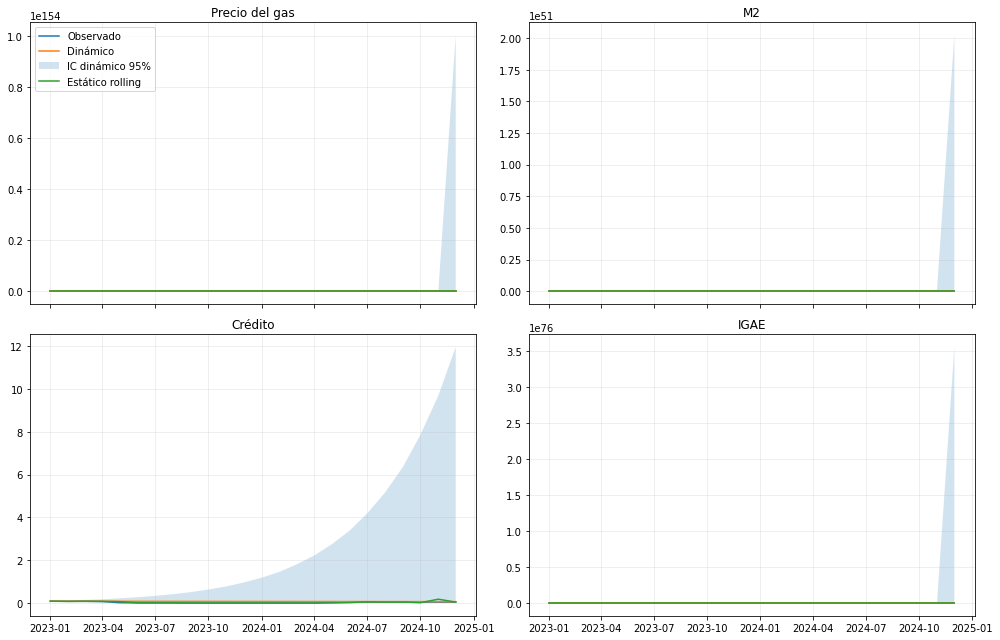

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

for ax, col in zip(axes.ravel(), LEVEL_COLUMNS):
    ax.plot(
        actual_levels.index,
        actual_levels[col],
        label="Observado"
    )
    ax.plot(
        dynamic_levels.index,
        dynamic_levels[col],
        label="Dinámico"
    )
    ax.fill_between(
        dynamic_levels.index,
        dynamic_levels_lower[col].astype(float),
        dynamic_levels_upper[col].astype(float),
        alpha=0.20,
        label="IC dinámico 95%"
    )
    ax.plot(
        rolling_levels.index,
        rolling_levels[col],
        label="Estático rolling"
    )
    ax.set_title(labels[col])

axes[0, 0].legend()
plt.tight_layout()
plt.show()

### 7.6 Pronóstico final posterior a la muestra

El VAR se reestima con toda la muestra. Se reportan pronósticos y límites del 95% en diferencias logarítmicas y en niveles.

Pronóstico final en diferencias


pronóstico                              límite inferior 95%  \
              dln_gas  dln_m2 dln_credito dln_igae             dln_gas   
2025-01-01    -8.0805 -0.1856     -0.0491  -0.3753            -21.3523   
2025-02-01     1.3423 -0.0039     -0.0883  -0.0578            -13.2118   
2025-03-01     0.4175  0.0589      0.0301  -0.0033            -14.3244   
2025-04-01    -0.1935 -0.0247     -0.0141  -0.1273            -15.0217   
2025-05-01     0.1349  0.0065     -0.0254  -0.1008            -14.7182   
2025-06-01     0.0561  0.0079     -0.0127  -0.0781            -14.7993   
2025-07-01     0.0640  0.0025     -0.0137  -0.0938            -14.7919   
2025-08-01     0.0687  0.0040     -0.0163  -0.0921            -14.7873   
2025-09-01     0.0627  0.0044     -0.0151  -0.0899            -14.7933   
2025-10-01     0.0663  0.0041     -0.0151  -0.0909            -14.7897   
2025-11-01     0.0654  0.0041     -0.0153  -0.0910            -14.7906   
2025-12-01     0.0652  0.0041     -0.0153  -0.0908            -14.7908   

                                        límite superior 95%         \
            dln_m2 dln_credito dln_igae             dln_gas dln_m2   
2025-01-01 -5.8635     -3.2867  -8.0941              5.1913 5.4924   
2025-02-01 -5.7688     -3.3777  -8.3566             15.8965 5.7611   
2025-03-01 -5.7064     -3.3463  -8.3569             15.1595 5.8242   
2025-04-01 -5.7923     -3.3977  -8.4994             14.6348 5.7429   
2025-05-01 -5.7613     -3.4104  -8.4735             14.9880 5.7744   
2025-06-01 -5.7600     -3.3979  -8.4511             14.9115 5.7758   
2025-07-01 -5.7654     -3.3990  -8.4669             14.9199 5.7704   
2025-08-01 -5.7639     -3.4016  -8.4652             14.9247 5.7719   
2025-09-01 -5.7635     -3.4004  -8.4631             14.9187 5.7723   
2025-10-01 -5.7638     -3.4003  -8.4640             14.9223 5.7720   
2025-11-01 -5.7638     -3.4006  -8.4641             14.9214 5.7720   
2025-12-01 -5.7638     -3.4005  -8.4639             14.9211 5.7720   

                                 
           dln_credito dln_igae  
2025-01-01      3.1885   7.3435  
2025-02-01      3.2012   8.2411  
2025-03-01      3.4065   8.3504  
2025-04-01      3.3695   8.2447  
2025-05-01      3.3596   8.2719  
2025-06-01      3.3725   8.2950  
2025-07-01      3.3715   8.2794  
2025-08-01      3.3689   8.2810  
2025-09-01      3.3701   8.2832  
2025-10-01      3.3702   8.2822  
2025-11-01      3.3699   8.2822  
2025-12-01      3.3700   8.2823

Pronóstico final en niveles


pronóstico                       límite inferior 95%         \
                  gas     m2 credito   igae                 gas     m2   
2025-01-01     0.0001 0.1911  0.0414 0.0000              0.0000 0.0007   
2025-02-01     0.0002 0.1903  0.0379 0.0000              0.0000 0.0000   
2025-03-01     0.0004 0.2019  0.0390 0.0000              0.0000 0.0000   
2025-04-01     0.0003 0.1969  0.0385 0.0000              0.0000 0.0000   
2025-05-01     0.0003 0.1982  0.0375 0.0000              0.0000 0.0000   
2025-06-01     0.0004 0.1998  0.0370 0.0000              0.0000 0.0000   
2025-07-01     0.0004 0.2003  0.0365 0.0000              0.0000 0.0000   
2025-08-01     0.0004 0.2011  0.0359 0.0000              0.0000 0.0000   
2025-09-01     0.0004 0.2020  0.0354 0.0000              0.0000 0.0000   
2025-10-01     0.0005 0.2028  0.0349 0.0000              0.0000 0.0000   
2025-11-01     0.0005 0.2036  0.0343 0.0000              0.0000 0.0000   
2025-12-01     0.0005 0.2045  0.0338 0.0000              0.0000 0.0000   

                                                         límite superior 95%  \
           credito   igae                                                gas   
2025-01-01  0.0016 0.0000                                            35.3079   
2025-02-01  0.0001 0.0000                                   282,900,856.4129   
2025-03-01  0.0000 0.0000                         1,084,767,420,486,532.2500   
2025-04-01  0.0000 0.0000                 2,461,169,955,008,317,751,296.0000   
2025-05-01  0.0000 0.0000         7,949,733,360,774,920,668,352,348,160.0000   
2025-06-01  0.0000 0.0000 23,785,796,252,190,306,858,344,638,148,771,840....   
2025-07-01  0.0000 0.0000 71,771,338,245,716,938,645,512,829,028,517,208,...   
2025-08-01  0.0000 0.0000 217,601,556,802,431,322,250,266,475,425,558,304...   
2025-09-01  0.0000 0.0000 655,823,099,680,179,286,013,287,157,846,873,186...   
2025-10-01  0.0000 0.0000 1,983,668,854,653,276,058,218,025,278,856,236,3...   
2025-11-01  0.0000 0.0000 5,994,655,110,422,979,544,168,287,232,687,308,7...   
2025-12-01  0.0000 0.0000 18,110,763,561,117,716,407,511,332,684,974,510,...   

                                                         \
                                                     m2   
2025-01-01                                      55.8583   
2025-02-01                                  17,746.0785   
2025-03-01                               6,004,961.9583   
2025-04-01                           1,873,299,837.9306   
2025-05-01                         603,104,250,998.5421   
2025-06-01                     194,432,812,010,526.0312   
2025-07-01                  62,349,090,770,751,704.0000   
2025-08-01              20,023,222,142,740,570,112.0000   
2025-09-01           6,432,825,015,212,935,479,296.0000   
2025-10-01       2,065,997,030,798,539,372,888,064.0000   
2025-11-01     663,542,568,950,007,369,421,553,664.0000   
2025-12-01 213,120,279,749,603,605,122,245,459,968.0000   

                                        \
                               credito   
2025-01-01                      1.0536   
2025-02-01                     25.8801   
2025-03-01                    780.5649   
2025-04-01                 22,687.3783   
2025-05-01                652,867.5204   
2025-06-01             19,032,439.1729   
2025-07-01            554,260,224.4171   
2025-08-01         16,099,660,661.3869   
2025-09-01        468,200,754,662.2323   
2025-10-01     13,616,728,091,990.7402   
2025-11-01    395,931,686,069,454.2500   
2025-12-01 11,513,024,121,356,660.0000   

                                                               
                                                         igae  
2025-01-01                                             0.0000  
2025-02-01                                             0.0059  
2025-03-01                                            24.8234  
2025-04-01                                        94,513.5879  
2025-05-01                                   369,779,

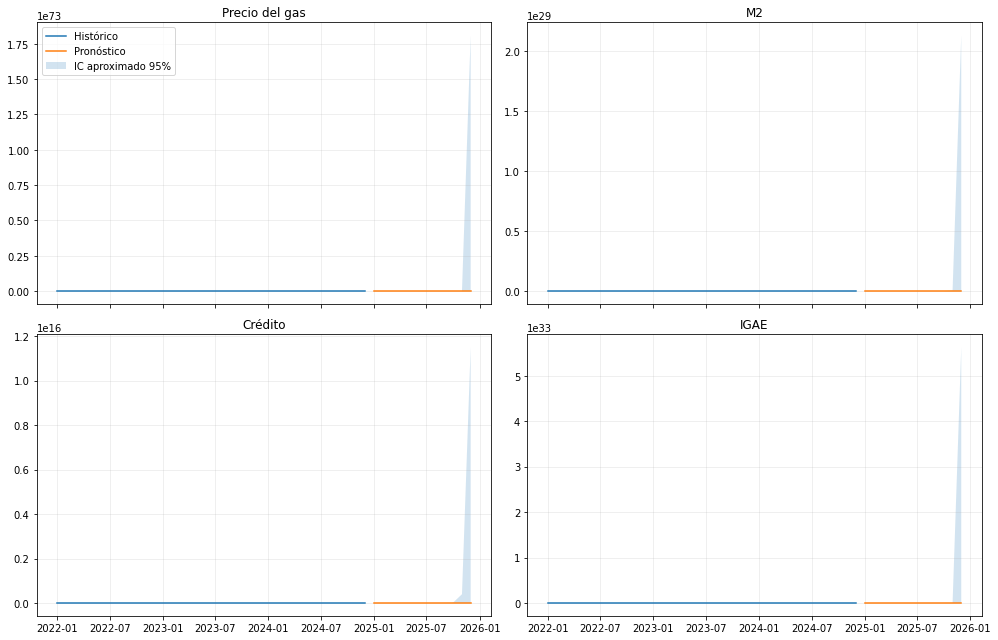

In [46]:
FORECAST_STEPS = 12
final_fit = VAR(y).fit(VAR_LAGS, trend="c")

point, lower, upper = final_fit.forecast_interval(
    y.to_numpy()[-VAR_LAGS:],
    steps=FORECAST_STEPS,
    alpha=0.05
)

future_index = pd.date_range(
    y.index[-1] + pd.offsets.MonthBegin(1),
    periods=FORECAST_STEPS,
    freq="MS"
)

forecast_final = pd.DataFrame(
    point, index=future_index, columns=ORDER
)
lower_final = pd.DataFrame(
    lower, index=future_index, columns=ORDER
)
upper_final = pd.DataFrame(
    upper, index=future_index, columns=ORDER
)

final_differences_table = pd.concat(
    {
        "pronóstico": forecast_final,
        "límite inferior 95%": lower_final,
        "límite superior 95%": upper_final
    },
    axis=1
)

print("Pronóstico final en diferencias")
display(final_differences_table)

final_levels, final_levels_lower, final_levels_upper = (
    reconstruct_dynamic_levels(
        data.iloc[-1],
        forecast_final,
        lower_final,
        upper_final
    )
)

final_levels_table = pd.concat(
    {
        "pronóstico": final_levels,
        "límite inferior 95%": final_levels_lower,
        "límite superior 95%": final_levels_upper
    },
    axis=1
)

print("Pronóstico final en niveles")
display(final_levels_table)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

for ax, col in zip(axes.ravel(), LEVEL_COLUMNS):
    ax.plot(
        data.index[-36:],
        data[col].iloc[-36:],
        label="Histórico"
    )
    ax.plot(
        future_index,
        final_levels[col],
        label="Pronóstico"
    )
    ax.fill_between(
        future_index,
        final_levels_lower[col].astype(float),
        final_levels_upper[col].astype(float),
        alpha=0.20,
        label="IC aproximado 95%"
    )
    ax.set_title(labels[col])

axes[0, 0].legend()
plt.tight_layout()
plt.show()

## 8. Comparación de los principales métodos de identificación estructural

| Método | ¿Dónde se imponen las restricciones? | ¿Qué significa una restricción? | ¿Cuántas restricciones para $K=4$? | Tipo de identificación |
|:-------|:--------------------------------------|:--------------------------------|:----------------------------------:|:------------------------|
| **Cholesky (corto plazo)** | Sobre la matriz de impacto contemporáneo $C_0$. | Un cero indica que un shock **no tiene efecto contemporáneo** sobre una variable ($h=0$). | 6 restricciones (ceros) | Exacta (Point Identification) |
| **Restricciones de largo plazo** | Sobre la matriz de efectos permanentes $$D(1)=\Phi(1)C_0,\qquad \Phi(1)=\sum_{h=0}^{\infty}\Phi_h.$$ | Un cero indica que un shock **no tiene efecto permanente** sobre una variable, aunque puede afectar su dinámica de corto y mediano plazo. | 6 restricciones independientes | Exacta (Point Identification) |
| **Restricciones de signo** | Sobre $C_0=\Theta_0$ o sobre las funciones de impulso-respuesta $$\Theta_h=\Phi_hC_0.$$ | Se exige que la respuesta de una variable sea positiva (+) o negativa (−) durante uno o varios horizontes. No se imponen ceros necesariamente. | No existe un número fijo de restricciones. Deben ser suficientes para seleccionar las rotaciones compatibles con la teoría económica. | Identificación por conjuntos (Set Identification) |

### Observaciones

- Los tres métodos parten del mismo VAR reducido estimado.
- Lo único que cambia es la forma de recuperar la matriz estructural $C_0$.
- Una vez identificada una matriz admisible $C_0$, pueden calcularse:
  - los shocks estructurales;
  - las funciones de impulso-respuesta (FIR);
  - las respuestas acumuladas;
  - la descomposición de la varianza del error de pronóstico (FEVD);
  - simulaciones y ejercicios de pronóstico estructural.

## 9. Pruebas automáticas de consistencia

In [47]:
# ============================================================
# Pruebas automáticas de consistencia
# ============================================================

# Si las FIR de largo plazo no están presentes, se reconstruyen
# a partir de C0_longrun antes de ejecutar las verificaciones.
if "IRF_longrun" not in globals() and "C0_longrun" in globals():
    IRF_longrun = structural_irfs(
        np.asarray(var_fit.coefs),
        C0_longrun,
        H
    )
    FEVD_longrun = compute_fevd(IRF_longrun)

required_objects = [
    "data",
    "STRUCTURAL_ORDER",
    "y",
    "ORDER",
    "Sigma_u",
    "C0",
    "IRF",
    "FEVD",
    "FEVD_longrun",
    "FEVD_sign_mean",
    "var_fit",
    "forecast_final",
    "boot_irf",
    "pred_dynamic",
    "pred_rolling",
    "test",
]

missing = [name for name in required_objects if name not in globals()]

if missing:
    raise RuntimeError(
        "No pueden ejecutarse las pruebas de consistencia porque "
        "faltan los siguientes objetos:\n- "
        + "\n- ".join(missing)
        + "\n\nEjecute la notebook mediante 'Restart & Run All'."
    )

checks = {
    "Orden de las series en niveles":
        list(data.columns) == STRUCTURAL_ORDER,

    "Orden de las variables estacionarias":
        list(y.columns) == ORDER,

    "Reconstrucción de Sigma_u mediante Cholesky":
        np.allclose(Sigma_u, C0 @ C0.T, atol=1e-10),

    "Impacto contemporáneo de las FIR Cholesky":
        np.allclose(IRF[0], C0, atol=1e-10),

    "FEVD Cholesky suma uno":
        np.allclose(FEVD.sum(axis=2), 1.0, atol=1e-10),

    "FEVD de largo plazo suma uno":
        np.allclose(FEVD_longrun.sum(axis=2), 1.0, atol=1e-10),

    "FEVD por signos suma uno":
        np.allclose(FEVD_sign_mean.sum(axis=2), 1.0, atol=1e-10),

    "Estabilidad del VAR":
        bool(var_fit.is_stable(verbose=False)),

    "Pronóstico final sin valores no finitos":
        np.isfinite(forecast_final.to_numpy()).all(),

    "Número suficiente de réplicas bootstrap":
        len(boot_irf) >= 100,

    "Dimensión del pronóstico dinámico":
        pred_dynamic.shape == test.shape,

    "Dimensión del pronóstico rolling":
        pred_rolling.shape == test.shape,
}

results = pd.DataFrame(
    {
        "Prueba": list(checks.keys()),
        "Resultado": [
            "✓ Superada" if value else "✗ Fallida"
            for value in checks.values()
        ],
    }
)

display(results)

failed = [name for name, value in checks.items() if not value]

if failed:
    raise AssertionError(
        "Fallaron las siguientes pruebas de consistencia:\n- "
        + "\n- ".join(failed)
    )

print("✓ Todas las pruebas automáticas fueron superadas.")


,Prueba,Resultado
0,Orden de las series en niveles,✓ Superada
1,Orden de las variables estacionarias,✓ Superada
2,Reconstrucción de Sigma_u mediante Cholesky,✓ Superada
3,Impacto contemporáneo de las FIR Cholesky,✓ Superada
4,FEVD Cholesky suma uno,✓ Superada
5,FEVD de largo plazo suma uno,✓ Superada
6,FEVD por signos suma uno,✓ Superada
7,Estabilidad del VAR,✓ Superada
8,Pronóstico final sin valores no finitos,✓ Superada
9,Número suficiente de réplicas bootstrap,✓ Superada


✓ Todas las pruebas automáticas fueron superadas.


## 10. Conclusiones y buenas prácticas

1. La base se carga una sola vez y alimenta todo el flujo.
2. Las ecuaciones se renderizan con celdas Markdown o `display(Math(...))`; `print()` se reserva para texto y resultados numéricos.
3. La identificación recursiva depende del orden económico de las variables.
4. Las FIR y la FEVD deben interpretarse conjuntamente y acompañarse de incertidumbre.
5. Los pronósticos puntuales provienen del VAR reducido; el SVAR añade interpretación estructural y permite construir escenarios.
6. Todo el código es general, visible y modificable por los alumnos.